In [2]:
import torch
import pandas as pd
import numpy as np
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# 1. กำหนด Device ให้อยู่บน GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. ดึงข้อมูลหุ้น (ตัวอย่างใช้หุ้นบางส่วนจาก S&P 500 เพื่อความรวดเร็วในการแสดงผล)
# ในการใช้งานจริง สามารถใส่รายชื่อ S&P 500 ทั้งหมดลงใน list ได้เลย
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'BRK-B', 'JNJ', 'JPM', 'V', 
           'PG', 'UNH', 'HD', 'NVDA', 'DIS', 'PYPL', 'MA', 'VZ', 'ADBE', 'NFLX'] 
data = yf.download(tickers, start='2023-01-01', end='2024-01-01')['Close']
returns = data.pct_change().dropna()

# 3. แปลงข้อมูลเป็น PyTorch Tensor และย้ายไปรันบน GPU
X = torch.tensor(returns.values, dtype=torch.float32, device=device)
n_samples, n_features = X.shape

# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    # ทำการ Center ข้อมูล
    X_centered = X - torch.mean(X, dim=0)
    
    # คำนวณ Sample Covariance
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    
    # กำหนด Target Matrix F (ใช้ Identity matrix ที่คูณด้วยค่าเฉลี่ยของ variance)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    
    # กำหนดค่า Shrinkage constant (delta) แบบคงที่ (หรือใช้สูตร analytical เพื่อหาค่า optimal)
    # ในตัวอย่างนี้ตั้งค่า delta = 0.2 เพื่อทำการดึงค่า covariance เข้าหา target
    delta = 0.2 
    
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov

shrunk_cov_gpu, sample_cov_gpu = ledoit_wolf_covariance_gpu(X)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก floating point error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)

# 6. คำนวณ Distance Matrix บน GPU: D = sqrt(0.5 * (1 - rho))
distance_matrix_gpu = torch.sqrt(0.5 * (1 - corr_matrix_gpu))

# 7. ย้ายข้อมูลกลับมาที่ CPU สำหรับ Hierarchical Clustering
distance_matrix_cpu = distance_matrix_gpu.cpu().numpy()

# แปลง Distance matrix เป็นแบบ Condensed format สำหรับ scipy linkage
condensed_dist = squareform(distance_matrix_cpu, checks=False)

# 8. ทำ Hierarchical Clustering (ใช้ Ward linkage)
Z = linkage(condensed_dist, method='ward')

# 9. แบ่งกลุ่มออกเป็น 10 Clusters
num_clusters = 10
cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')

# 10. เลือกหุ้น 10 ตัว (1 ตัวแทนจากแต่ละ Cluster)
# กลยุทธ์: เลือกหุ้นที่มีความผันผวน (Variance) ต่ำที่สุดในแต่ละ Cluster
variances_cpu = torch.diag(sample_cov_gpu).cpu().numpy()
selected_stocks = []

for i in range(1, num_clusters + 1):
    cluster_indices = np.where(cluster_labels == i)[0]
    
    # หา index ของหุ้นในกลุ่มนี้ที่มี variance ต่ำที่สุด
    min_var_idx = cluster_indices[np.argmin(variances_cpu[cluster_indices])]
    
    ticker_name = returns.columns[min_var_idx]
    selected_stocks.append(ticker_name)

print("\n=== รายชื่อหุ้น 10 ตัวที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===")
for idx, stock in enumerate(selected_stocks, 1):
    print(f"{idx}. {stock}")

[**********************55%*                      ]  11 of 20 completed

Using device: cuda


[*********************100%***********************]  20 of 20 completed



=== รายชื่อหุ้น 10 ตัวที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===
1. GOOGL
2. AAPL
3. NFLX
4. JNJ
5. PG
6. UNH
7. V
8. BRK-B
9. HD
10. VZ


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print('✅ Libraries loaded successfully!')

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7)'}
resp = requests.get(url, headers=headers, timeout=30)
from io import StringIO
tables = pd.read_html(StringIO(resp.text))
df_sp500 = tables[0]  # ตารางแรกคือ constituents

# หา column ชื่อ Symbol/Ticker และ GICS Sector
sym_col = [c for c in df_sp500.columns if 'Symbol' in str(c) or 'Ticker' in str(c)][0]
sec_col = [c for c in df_sp500.columns if 'GICS Sector' in str(c)][0]

sp500_tickers = df_sp500[sym_col].str.replace('.', '-', regex=False).tolist()
sp500_sector_map = dict(zip(
    df_sp500[sym_col].str.replace('.', '-', regex=False),
    df_sp500[sec_col]
))

print(f"  ✅ ได้ {len(sp500_tickers)} ตัว")

✅ Libraries loaded successfully!
  ✅ ได้ 503 ตัว


In [10]:
sp500_tickers

['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ARES',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK-B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF-B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'CCL',
 'CARR',
 'CVNA',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CIEN',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COHR',
 'COIN',
 'CL',
 'CMCSA',
 'FIX',
 'C

In [12]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# 1. กำหนด Device ให้อยู่บน GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



# 2. ดึงข้อมูลหุ้น 
print("Downloading data...")
# หมายเหตุ: สามารถใช้ sp500_tickers[:50] เพื่อทดสอบกับหุ้น 50 ตัวแรกก่อนได้หากต้องการความรวดเร็ว
data = yf.download(sp500_tickers, start='2010-01-01', end='2024-01-01')['Close']

# --- จัดการ Missing Data ---
# ตัดหุ้นที่มีข้อมูลหายไปมากกว่า 10% ออก (รับรองว่ามีข้อมูลอย่างน้อย 90%)
threshold = int(data.shape[0] * 0.9)
data = data.dropna(axis=1, thresh=threshold)
# เติมข้อมูลในวันที่หายไปด้วยราคาของวันก่อนหน้า (Forward Fill) และวันถัดไป (Backward Fill)
data = data.ffill().bfill()

valid_tickers = data.columns

# 3. แปลงข้อมูลราคาเป็น PyTorch Tensor และย้ายไปรันบน GPU
prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# [ส่วนที่แก้ไข] คำนวณ Log Return บน GPU โดยตรงแทน Numpy
# log(P_t / P_{t-1})
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])

n_samples, n_features = returns_gpu.shape

# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    # ทำการ Center ข้อมูล
    X_centered = X - torch.mean(X, dim=0)
    
    # คำนวณ Sample Covariance
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    
    # กำหนด Target Matrix F 
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    
    # กำหนดค่า Shrinkage constant (delta)
    delta = 0.2 
    
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov

shrunk_cov_gpu, sample_cov_gpu = ledoit_wolf_covariance_gpu(returns_gpu)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก floating point error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)

# 6. คำนวณ Distance Matrix บน GPU: D = sqrt(0.5 * (1 - rho))
distance_matrix_gpu = torch.sqrt(0.5 * (1 - corr_matrix_gpu))

# 7. ย้ายข้อมูลกลับมาที่ CPU สำหรับ Hierarchical Clustering
# (Scipy Linkage ไม่รองรับ GPU Tensor จึงจำเป็นต้องใช้ Numpy บน CPU ในขั้นตอนนี้)
distance_matrix_cpu = distance_matrix_gpu.cpu().numpy()

# แปลง Distance matrix เป็นแบบ Condensed format สำหรับ scipy linkage
condensed_dist = squareform(distance_matrix_cpu, checks=False)

# 8. ทำ Hierarchical Clustering (ใช้ Ward linkage)
Z = linkage(condensed_dist, method='ward')

# 9. แบ่งกลุ่มออกเป็น 10 Clusters
num_clusters = 10
cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')

# 10. เลือกหุ้น 10 ตัว (1 ตัวแทนจากแต่ละ Cluster)
# ดึงค่า Variance ของแต่ละหุ้นกลับมาประมวลผลบน CPU
variances_cpu = torch.diag(sample_cov_gpu).cpu().numpy()
selected_stocks = []

for i in range(1, num_clusters + 1):
    # ค้นหา index ของหุ้นที่อยู่ในกลุ่มที่ i
    cluster_indices = (cluster_labels == i).nonzero()[0]
    
    # หา index ของหุ้นในกลุ่มนี้ที่มี variance ต่ำที่สุด
    min_var_idx = cluster_indices[variances_cpu[cluster_indices].argmin()]
    
    ticker_name = valid_tickers[min_var_idx]
    selected_stocks.append(ticker_name)

print("\n=== รายชื่อหุ้น 10 ตัวที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===")
for idx, stock in enumerate(selected_stocks, 1):
    print(f"{idx}. {stock}")

Using device: cuda


[*************         27%                       ]  136 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1704085200")
[**********************73%**********             ]  367 of 503 completed$Q: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1704085200")
[**********************90%******************     ]  452 of 503 completed$SOLV: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1704085200")
[**********************96%*********************  ]  485 of 503 completed$GEV: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-01-01) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1704085200")
[*********************100%***********************]  503 of 503 c


=== รายชื่อหุ้น 10 ตัวที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===
1. PG
2. JNJ
3. DUK
4. PSA
5. IBM
6. BDX
7. XOM
8. BRK-B
9. LIN
10. MCD


In [22]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# 1. กำหนด Device ให้อยู่บน GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# กำหนดรายชื่อหุ้น (ทดสอบด้วย 12 ตัว)

# 2. ดึงข้อมูลหุ้น 
# print("Downloading data...")
# data = yf.download(sp500_tickers, start='2010-01-01', end='2024-01-01')['Close']

# --- จัดการ Missing Data ---
threshold = int(data.shape[0] * 0.9)
data = data.dropna(axis=1, thresh=threshold)
data = data.ffill().bfill()

valid_tickers = data.columns

# 3. แปลงข้อมูลราคาเป็น PyTorch Tensor และย้ายไปรันบน GPU
prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape

# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    X_centered = X - torch.mean(X, dim=0)
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    delta = 0.2 
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov

shrunk_cov_gpu, sample_cov_gpu = ledoit_wolf_covariance_gpu(returns_gpu)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)

# 6. คำนวณ Distance Matrix บน GPU ตามสมการอ้างอิง: D = sqrt(0.5 * (1 - rho))
distance_matrix_gpu = torch.sqrt(0.5 * (1 - corr_matrix_gpu))

# บังคับให้ระยะทางของหุ้นตัวเดียวกัน (เส้นทแยงมุม) เป็น 0 เสมอ
distance_matrix_gpu.fill_diagonal_(0.0)

# 7. ย้ายข้อมูลกลับมาที่ CPU สำหรับ Hierarchical Clustering
distance_matrix_cpu = distance_matrix_gpu.cpu().numpy()

# แปลง Distance matrix เป็น Condensed format สำหรับ scipy linkage
condensed_dist = squareform(distance_matrix_cpu, checks=False)

# 8. ทำ Hierarchical Clustering (ใช้ 'ward' linkage ได้ตามความเหมาะสมของ Distance metric นี้)
Z = linkage(condensed_dist, method='ward')

# 9. แบ่งกลุ่มออกเป็น 10 Clusters
num_clusters = min(30, len(valid_tickers))
cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')

# 10. เลือกหุ้น 1 ตัวแทนจากแต่ละ Cluster ที่มีความเสี่ยง (Variance) ต่ำสุด
variances_cpu = torch.diag(sample_cov_gpu).cpu().numpy()
selected_stocks = []

for i in range(1, num_clusters + 1):
    cluster_indices = (cluster_labels == i).nonzero()[0]
    min_var_idx = cluster_indices[variances_cpu[cluster_indices].argmin()]
    ticker_name = valid_tickers[min_var_idx]
    selected_stocks.append(ticker_name)

print("\n=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===")
for idx, stock in enumerate(selected_stocks, 1):
    print(f"{idx}. {stock}")

Using device: cuda

=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนความเสี่ยงต่ำจากแต่ละกลุ่ม) ===
1. PEP
2. PG
3. WMT
4. NEM
5. LMT
6. WRB
7. WM
8. JNJ
9. UNH
10. CVS
11. DGX
12. DUK
13. PSA
14. MAA
15. TXN
16. IBM
17. BDX
18. VRSK
19. MSFT
20. GEN
21. XOM
22. BRK-B
23. CTRA
24. ADM
25. UPS
26. ROP
27. LIN
28. SYY
29. NVR
30. MCD


In [ ]:
import torch
import pandas as pd
import yfinance as yf
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import math

# 1. กำหนด Device ให้อยู่บน GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# --- จัดการ Missing Data ---
threshold = int(data.shape[0] * 0.9)
data = data.dropna(axis=1, thresh=threshold)
data = data.ffill().bfill()

valid_tickers = data.columns

# 3. แปลงข้อมูลราคาเป็น PyTorch Tensor และย้ายไปรันบน GPU
prices_tensor = torch.tensor(data.values, dtype=torch.float32, device=device)

# คำนวณ Log Return บน GPU
returns_gpu = torch.log(prices_tensor[1:] / prices_tensor[:-1])
n_samples, n_features = returns_gpu.shape

# 4. สร้างฟังก์ชันคำนวณ Ledoit-Wolf Shrinkage Covariance บน PyTorch
def ledoit_wolf_covariance_gpu(X):
    X_centered = X - torch.mean(X, dim=0)
    sample_cov = torch.matmul(X_centered.T, X_centered) / (n_samples - 1)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = torch.eye(n_features, device=device) * mean_var
    delta = 0.2 
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    return shrunk_cov, sample_cov


def ledoit_wolf_covariance_gpu_dynamic(X):
    n_samples, n_features = X.shape
    
    # 1. ทำ Data Centering
    X_centered = X - torch.mean(X, dim=0)
    
    # 2. คำนวณ Sample Covariance (S) 
    # ทฤษฎี LW ดั้งเดิมมักใช้ n_samples แทน n_samples-1 เพื่อความสะดวกในสูตรคณิตศาสตร์
    sample_cov = torch.matmul(X_centered.T, X_centered) / n_samples
    
    # 3. คำนวณ Target Covariance (T)
    mean_var = torch.trace(sample_cov) / n_features
    target_cov = mean_var * torch.eye(n_features, device=X.device)
    
    # ---------------------------------------------------------
    # ส่วนที่เพิ่มเข้ามา: คำนวณ Dynamic Delta (Optimal Shrinkage)
    # ---------------------------------------------------------
    
    # คำนวณ Squared Distance ระหว่าง Sample Covariance และ Target (d^2)
    d_squared = torch.sum((sample_cov - target_cov) ** 2)
    
    # คำนวณ Variance ของสมาชิกใน Sample Covariance (b^2)
    # ใช้การคูณแบบ Element-wise ของข้อมูลที่ Center แล้ว
    X_squared = X_centered ** 2
    # ค่าประมาณความแปรปรวนแบบ Asymptotic
    b_squared = torch.sum((torch.matmul(X_squared.T, X_squared) / n_samples) - (sample_cov ** 2)) / n_samples
    
    # คำนวณค่า Optimal Delta แบบ Dynamic
    # ป้องกันกรณีที่ b_squared มากกว่า d_squared หรือค่า delta หลุดกรอบ [0, 1]
    delta = b_squared / d_squared
    delta = torch.clamp(delta, min=0.0, max=1.0)
    
    # ---------------------------------------------------------
    
    # 4. คำนวณ Shrunk Covariance
    shrunk_cov = (1 - delta) * sample_cov + delta * target_cov
    
    return shrunk_cov, sample_cov, delta.item()


shrunk_cov_gpu, sample_cov_gpu, _ = ledoit_wolf_covariance_gpu_dynamic(returns_gpu)

# 5. แปลงเป็น Correlation Matrix
vols = torch.sqrt(torch.diag(shrunk_cov_gpu))
outer_vols = torch.outer(vols, vols)
corr_matrix_gpu = shrunk_cov_gpu / outer_vols

# ป้องกันค่าที่เกินขอบเขต [-1, 1] จาก Floating Point Error
corr_matrix_gpu = torch.clamp(corr_matrix_gpu, -1.0, 1.0)

# 6. คำนวณ Distance Matrix บน GPU: D = sqrt(0.5 * (1 - rho))
distance_matrix_gpu = torch.sqrt(0.5 * (1 - corr_matrix_gpu))
distance_matrix_gpu.fill_diagonal_(0.0)

# 7. ย้ายข้อมูลกลับมาที่ CPU สำหรับ Hierarchical Clustering
distance_matrix_cpu = distance_matrix_gpu.cpu().numpy()

# แปลง Distance matrix เป็น Condensed format 
condensed_dist = squareform(distance_matrix_cpu, checks=False)

# 8. ทำ Hierarchical Clustering (Ward linkage)
Z = linkage(condensed_dist, method='ward')

# 9. แบ่งกลุ่มออกเป็น 10 Clusters
num_clusters = min(30, len(valid_tickers))
cluster_labels = fcluster(Z, num_clusters, criterion='maxclust')

# ---------------------------------------------------------
# 10. เลือกหุ้น 1 ตัวแทนจากแต่ละ Cluster ด้วย Annualised Sharpe Ratio สูงสุด
# ---------------------------------------------------------

# คำนวณ Mean Return รายวันบน GPU
mean_returns_gpu = torch.mean(returns_gpu, dim=0)

# ดึงค่า Volatility รายวัน (Standard Deviation) จากแนวทแยงมุมของ Shrunk Covariance
vols_gpu = torch.sqrt(torch.diag(shrunk_cov_gpu))

# คำนวณ Annualised Sharpe Ratio บน GPU
sharpe_ratios_gpu = math.sqrt(252) * (mean_returns_gpu / vols_gpu)

# ย้ายข้อมูล Sharpe Ratio กลับมาที่ CPU เพื่อใช้คัดกรองกับ Cluster Labels
sharpe_ratios_cpu = sharpe_ratios_gpu.cpu().numpy()

selected_stocks = []

for i in range(1, num_clusters + 1):
    cluster_indices = (cluster_labels == i).nonzero()[0]
    
    # หา index ของหุ้นในกลุ่มนี้ที่มี Sharpe Ratio สูงที่สุด (argmax)
    max_sharpe_idx = cluster_indices[sharpe_ratios_cpu[cluster_indices].argmax()]
    
    ticker_name = valid_tickers[max_sharpe_idx]
    selected_stocks.append(ticker_name)

print("\n=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนที่มี Annualised Sharpe Ratio สูงสุดจากแต่ละกลุ่ม) ===")
for idx, stock in enumerate(selected_stocks, 1):
    print(f"{idx}. {stock}")

Using device: cuda

=== รายชื่อหุ้นที่ถูกคัดเลือก (ตัวแทนที่มี Annualised Sharpe Ratio สูงสุดจากแต่ละกลุ่ม) ===
1. AWK
2. SBAC
3. EXR
4. TPL
5. BRK-B
6. BKNG
7. ODFL
8. ROP
9. LYB
10. APH
11. CHTR
12. CTAS
13. NVR
14. ORLY
15. COST
16. DPZ
17. SW
18. AVGO
19. WST
20. CDNS
21. CPRT
22. KDP
23. CHD
24. NOC
25. NDAQ
26. AJG
27. LLY
28. UNH
29. COR
30. HCA



=== สรุปผลตอบแทน ความผันผวน และเปรียบเทียบ Sharpe Ratios ===
       Annual Return (%)  Annual Vol (%)  Sharpe (Log Return)  \
Stock                                                           
DPZ            29.037001       29.834801               0.9733   
COST           19.608999       20.442699               0.9592   
CTAS           23.861000       25.025299               0.9535   
LLY            22.885599       24.349899               0.9399   
AJG            19.264299       20.743299               0.9287   
ODFL           27.703800       30.237301               0.9162   
CDNS           27.165300       30.101400               0.9025   
AVGO           31.553101       35.213200               0.8961   
ORLY           22.944700       25.851900               0.8875   
CPRT           21.969101       25.632999               0.8571   
UNH            21.640699       25.330400               0.8543   
EXR            21.967800       26.219400               0.8378   
WST            21.426001    

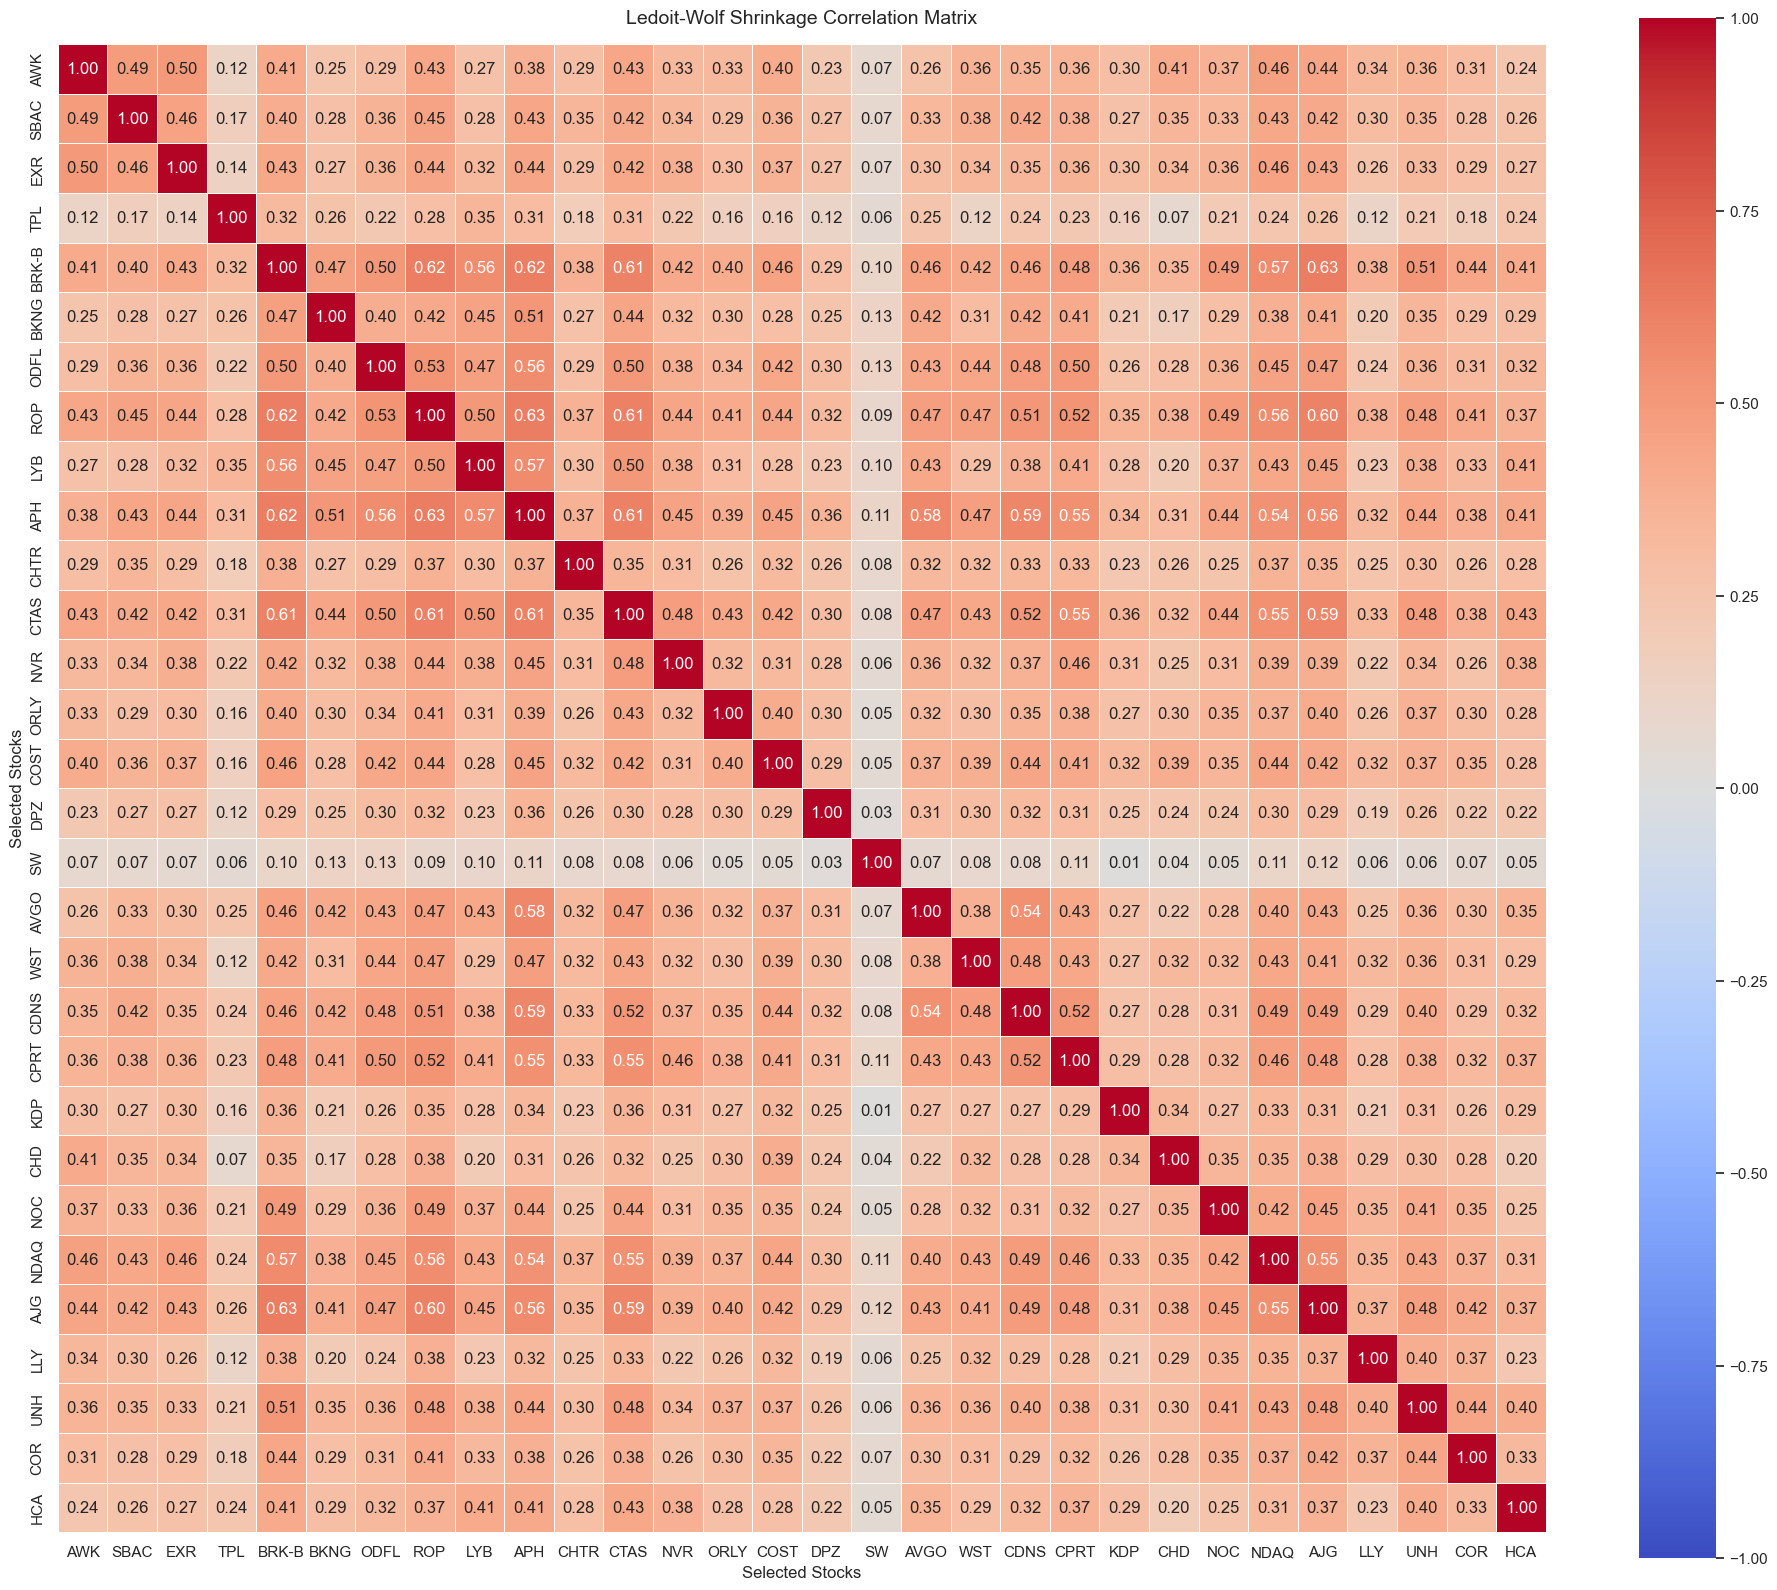

In [34]:
# ---------------------------------------------------------
# 11. เปรียบเทียบ Annualised Sharpe Ratios (Log Return vs Normal Return)
#     พร้อมแสดง Annual Return (%) และ Annual Vol (%)
# ---------------------------------------------------------

# หาดัชนี (Indices) ของหุ้นที่ถูกคัดเลือกจากรายชื่อหุ้นทั้งหมด
selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]

# --- 11.1 คำนวณ Sharpe Ratio แบบ Normal (Simple) Return บน GPU ---
# Normal Return = (P_t / P_{t-1}) - 1
norm_returns_gpu = (prices_tensor[1:] / prices_tensor[:-1]) - 1.0

# คำนวณค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายวันของ Normal Return บน GPU
mean_norm_returns_gpu = torch.mean(norm_returns_gpu, dim=0)
std_norm_returns_gpu = torch.std(norm_returns_gpu, dim=0, unbiased=True)

# คำนวณ Annualised Sharpe Ratio สำหรับ Normal Return
sharpe_ratios_norm_gpu = math.sqrt(252) * (mean_norm_returns_gpu / std_norm_returns_gpu)

# ย้ายผลลัพธ์ Sharpe ของ Normal Return กลับมาที่ CPU
sharpe_ratios_norm_cpu = sharpe_ratios_norm_gpu.cpu().numpy()

# --- 11.2 คำนวณ Annual Return (%) และ Annual Vol (%) จาก Log Return ---
# ใช้ mean_returns_gpu และ vols_gpu ที่คำนวณไว้แล้วในขั้นตอนที่ 10
ann_returns_cpu = mean_returns_gpu.cpu().numpy() * 252 * 100
ann_vols_cpu = vols_gpu.cpu().numpy() * math.sqrt(252) * 100

# --- 11.3 ดึงข้อมูลเฉพาะหุ้นที่ถูกคัดเลือกและสร้างตารางเปรียบเทียบ ---
selected_sharpe_log = sharpe_ratios_cpu[selected_indices]
selected_sharpe_norm = sharpe_ratios_norm_cpu[selected_indices]
selected_ann_returns = ann_returns_cpu[selected_indices]
selected_ann_vols = ann_vols_cpu[selected_indices]

# สร้างตาราง DataFrame
df_summary = pd.DataFrame({
    'Stock': selected_stocks,
    'Annual Return (%)': selected_ann_returns,
    'Annual Vol (%)': selected_ann_vols,
    'Sharpe (Log Return)': selected_sharpe_log,
    'Sharpe (Normal Return)': selected_sharpe_norm
})
df_summary.set_index('Stock', inplace=True)

# เพิ่มคอลัมน์เพื่อดูส่วนต่างของ Sharpe Ratio
df_summary['Difference (Norm - Log)'] = df_summary['Sharpe (Normal Return)'] - df_summary['Sharpe (Log Return)']

# เรียงลำดับตาม Sharpe Ratio ของ Log Return จากมากไปน้อย
df_summary = df_summary.sort_values(by='Sharpe (Log Return)', ascending=False)

print("\n=== สรุปผลตอบแทน ความผันผวน และเปรียบเทียบ Sharpe Ratios ===")
print(df_summary.round(4))

# --- 11.4 ดึง Ledoit-Wolf Shrinkage Correlation Matrix เฉพาะหุ้นที่เลือก ---
# ทำการ Slice Tensor บน GPU โดยตรง
selected_corr_tensor = corr_matrix_gpu[selected_indices][:, selected_indices]

# ย้ายผลลัพธ์กลับมาที่ CPU เพื่อใช้งานกับ Pandas
selected_corr_matrix = selected_corr_tensor.cpu().numpy()

# สร้างตาราง DataFrame สำหรับ Correlation Matrix
df_corr = pd.DataFrame(
    selected_corr_matrix, 
    index=selected_stocks, 
    columns=selected_stocks
)

print("\n=== Ledoit-Wolf Shrinkage Correlation Matrix ของกลุ่มตัวแทน ===")

import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าขนาดของกราฟ
plt.figure(figsize=(24, 20)) # ปรับขนาดกราฟให้พอดีหน้าจอมากขึ้น (24x16 อาจจะใหญ่เกินไปสำหรับบางจอ)

# สร้าง Heatmap
sns.heatmap(
    df_corr, 
    annot=True,          
    cmap='coolwarm',     
    vmin=-1.0,           
    vmax=1.0,            
    fmt=".2f",           
    linewidths=0.5,      
    square=True,         
)

# กำหนดชื่อกราฟ
plt.title('Ledoit-Wolf Shrinkage Correlation Matrix', fontsize=14, pad=15)
plt.xlabel('Selected Stocks')
plt.ylabel('Selected Stocks')

# แสดงผลกราฟ
plt.show()


--- Starting Phase 2: EBGWO Weight Optimization ---
Optimizing weights for the following 30 selected assets...

--- GPU EBGWO Weighting Complete ---
Annualized Return:      25.00%
Annualized Volatility:  16.59%
Maximized Sharpe Ratio: 1.2456
------------------------------------

Final Optimal Portfolio Weights (Weights > 1%):
  Ticker Weight
0    LLY 21.81%
1    DPZ 19.87%
2    TPL 11.26%
3   ORLY  9.49%
4   COST  8.47%
5   ODFL  7.95%
6   AVGO  7.33%
7    EXR  7.18%
8    KDP  3.79%
9     SW  2.85%


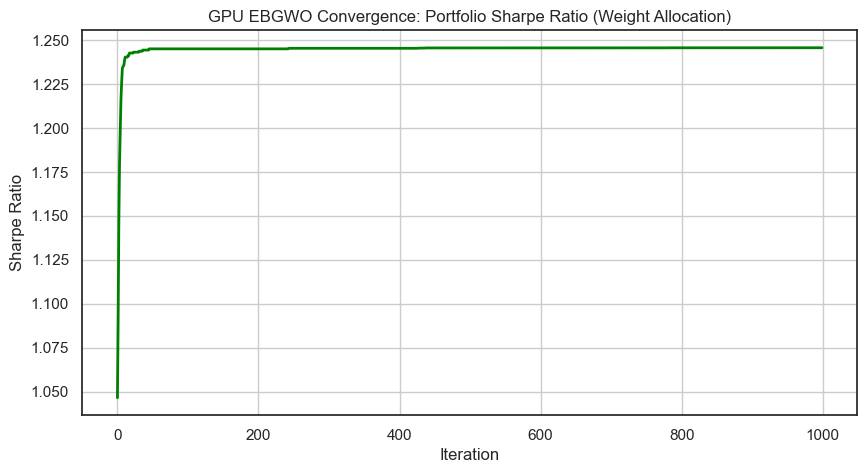

In [39]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# Step 6: Setup EBGWO for Weight Optimization on Selected Assets
# ---------------------------------------------------------
print("\n--- Starting Phase 2: EBGWO Weight Optimization ---")

# กำหนดตัวแปรคงที่สำหรับการคำนวณ
RISK_FREE_RATE = 0.0434
sqrt_252 = math.sqrt(252)

# ใช้ selected_indices จากผลลัพธ์ของ Clustering ในขั้นตอนก่อนหน้า
num_subset_assets = len(selected_indices)
print(f"Optimizing weights for the following {num_subset_assets} selected assets...")

# ดึงข้อมูล Log Return เฉพาะหุ้นตัวแทนที่ถูกเลือก
# Shape: (Days, num_subset_assets)
subset_returns = returns_gpu[:, selected_indices]

# EBGWO Hyperparameters
num_wolves = 500
weight_iterations = 1000
ST = 0.6  # Search Tendency: 20% chance to explore using a random wolf

# Initialize wolf population randomly in continuous space
# Shape: (100, num_subset_assets)
wolves = torch.rand((num_wolves, num_subset_assets), dtype=torch.float32, device=device)

# Enforce Portfolio Constraint (Weights must sum to 1)
wolves = wolves / wolves.sum(dim=1, keepdim=True)

best_weights_global = None
best_sharpe_global = -np.inf
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized EBGWO for Weights
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. FAST Portfolio Sharpe Calculation
    # Resulting portfolio_returns shape: (Days, wolves)
    portfolio_returns = torch.matmul(subset_returns, wolves.T)
    
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # Fitness is the Sharpe Ratio
    fitnesses = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. Identify the Alpha, Beta, and Delta wolves (Top 3 Performers)
    sorted_indices_wolves = torch.argsort(fitnesses, descending=True)
    
    alpha_pos = wolves[sorted_indices_wolves[0]].clone()
    beta_pos = wolves[sorted_indices_wolves[1]].clone()
    delta_pos = wolves[sorted_indices_wolves[2]].clone()
    
    alpha_sharpe = fitnesses[sorted_indices_wolves[0]].item()
    
    # Update global best tracking
    if alpha_sharpe > best_sharpe_global:
        best_sharpe_global = alpha_sharpe
        best_weights_global = alpha_pos.cpu().numpy()
        
    weight_convergence.append(best_sharpe_global)
    
    # 3. Position Update (EBGWO Core Mechanics)
    # Parameter 'a' decreases linearly from 2 to 0 to shift from exploration to exploitation
    a = 2.0 - iteration * (2.0 / weight_iterations)
    
    # --- Distance to Alpha ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A1 = 2 * a * r1 - a
    C1 = 2 * r2
    D_alpha = torch.abs(C1 * alpha_pos - wolves)
    X1 = alpha_pos - A1 * D_alpha
    
    # --- Distance to Beta ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A2 = 2 * a * r1 - a
    C2 = 2 * r2
    D_beta = torch.abs(C2 * beta_pos - wolves)
    X2 = beta_pos - A2 * D_beta
    
    # --- Distance to Delta / Random (Enhanced Balance Mechanism) ---
    r1 = torch.rand_like(wolves)
    r2 = torch.rand_like(wolves)
    A3 = 2 * a * r1 - a
    C3 = 2 * r2
    
    # Create an exploration mask based on the Search Tendency (ST) parameter
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    
    # Dynamically replace Delta with a random wolf for structural exploration
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    D_delta = torch.abs(C3 * delta_or_random_pos - wolves)
    X3 = delta_or_random_pos - A3 * D_delta
    
    # 4. Update internal positions based on the average adjustments
    new_wolves = (X1 + X2 + X3) / 3.0
    
    # 5. Enforce Portfolio Constraints (Non-negative weights that sum to 1)
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    
    # Safeguard against zero-division
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio & Metrics
# ---------------------------------------------------------

# คำนวณ Final Portfolio Metrics ด้วยน้ำหนักที่ดีที่สุด (Alpha)
final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_port_returns = torch.matmul(subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Annualized Return:      {final_ann_return:.2%}")
print(f"Annualized Volatility:  {final_ann_vol:.2%}")
print(f"Maximized Sharpe Ratio: {best_sharpe_global:.4f}")
print("------------------------------------")

# สร้าง DataFrame จัดเก็บพอร์ตโฟลิโอโดยใช้ selected_stocks
final_portfolio_df = pd.DataFrame({
    'Ticker': selected_stocks,
    'Weight': best_weights_global
})

# กรองหุ้นที่มีน้ำหนักน้อยกว่า 1% ออกเพื่อความสะอาดของข้อมูล และเรียงลำดับจากมากไปน้อย
final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.001]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights (Weights > 1%):")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, color='green', linewidth=2)
plt.title('GPU EBGWO Convergence: Portfolio Sharpe Ratio (Weight Allocation)')
plt.xlabel('Iteration')
plt.ylabel('Sharpe Ratio')
plt.grid(True)
plt.show()


--- Starting Phase 2: Robust EBGWO Weight Optimization ---
Optimizing weights for the following 30 selected assets with MAX_WEIGHT = 15.0%...

--- GPU EBGWO Weighting Complete ---
Annualized Return:      24.82%
Annualized Volatility:  16.87%
Downside Volatility:    10.46%
Maximized Sortino Ratio:1.9583
------------------------------------

Final Optimal Portfolio Weights (Weights > 0.1%):
  Ticker Weight
0    LLY 15.00%
1    DPZ 15.00%
2   COST 14.97%
3   ORLY 13.46%
4    TPL 12.27%
5   AVGO 10.55%
6    EXR  9.47%
7    WST  9.28%


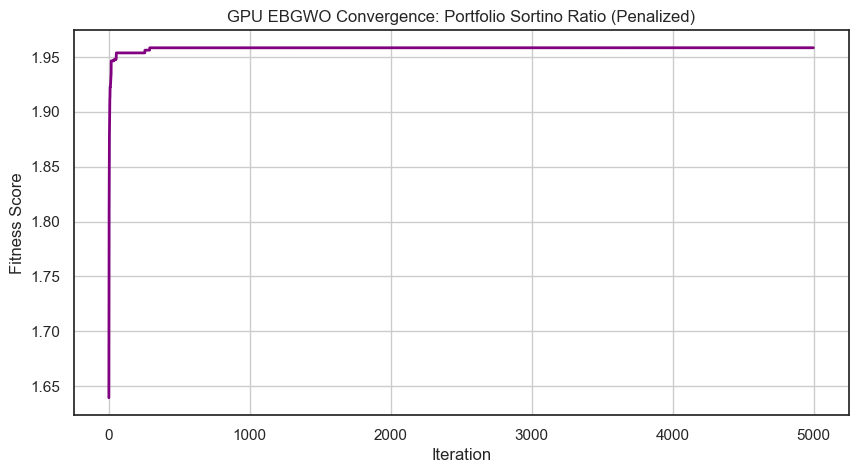

In [44]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# ---------------------------------------------------------
# Step 6: Setup EBGWO for Weight Optimization (Robust for Future Data)
# ---------------------------------------------------------
print("\n--- Starting Phase 2: Robust EBGWO Weight Optimization ---")

# กำหนดตัวแปรคงที่
RISK_FREE_RATE = 0.0434
sqrt_252 = math.sqrt(252)
MAX_WEIGHT = 0.15  # กำหนดน้ำหนักสูงสุดที่ 15% ต่อหุ้น 1 ตัว เพื่อป้องกัน Overfitting กับหุ้นที่ขึ้นแรงผิดปกติ

num_subset_assets = len(selected_indices)
print(f"Optimizing weights for the following {num_subset_assets} selected assets with MAX_WEIGHT = {MAX_WEIGHT*100}%...")

# ดึงข้อมูล Log Return เฉพาะหุ้นตัวแทนที่ถูกเลือก
subset_returns = returns_gpu[:, selected_indices]

# EBGWO Hyperparameters
num_wolves = 500
weight_iterations = 5000
ST = 0.6  # Search Tendency

# Initialize wolf population
wolves = torch.rand((num_wolves, num_subset_assets), dtype=torch.float32, device=device)
wolves = wolves / wolves.sum(dim=1, keepdim=True)

best_weights_global = None
best_fitness_global = -np.inf # เปลี่ยนชื่อจาก sharpe เป็น fitness เพราะเราใช้ Sortino + Penalty
weight_convergence = []

# ---------------------------------------------------------
# Step 7: Run Vectorized EBGWO (Objective: Sortino Ratio with Penalties)
# ---------------------------------------------------------
for iteration in range(weight_iterations):
    
    # 1. คำนวณผลตอบแทนพอร์ตโฟลิโอ
    portfolio_returns = torch.matmul(subset_returns, wolves.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    
    # 1.1 คำนวณ Downside Deviation สำหรับ Sortino Ratio (สนใจเฉพาะวันที่พอร์ตติดลบ)
    downside_returns = torch.where(portfolio_returns < 0, portfolio_returns, torch.zeros_like(portfolio_returns))
    port_downside_vol = downside_returns.std(dim=0, unbiased=True) * sqrt_252
    
    # 1.2 คำนวณ Sortino Ratio (แทนที่ Sharpe Ratio เดิม)
    sortino_ratios = torch.where(port_downside_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_downside_vol, torch.zeros_like(port_ann_return))
    
    # 1.3 ใช้ Penalty Function ลงโทษพอร์ตโฟลิโอที่มีน้ำหนักหุ้นเกิน MAX_WEIGHT
    # ถ้าน้ำหนักเกิน 15% จะถูกหักคะแนน Fitness อย่างหนัก เพื่อบังคับให้หมาป่าหาคำตอบที่กระจายความเสี่ยง
    weight_penalties = torch.sum(torch.relu(wolves - MAX_WEIGHT), dim=1) * 100.0
    fitnesses = sortino_ratios - weight_penalties
    
    # 2. Identify Alpha, Beta, Delta wolves
    sorted_indices_wolves = torch.argsort(fitnesses, descending=True)
    
    alpha_pos = wolves[sorted_indices_wolves[0]].clone()
    beta_pos = wolves[sorted_indices_wolves[1]].clone()
    delta_pos = wolves[sorted_indices_wolves[2]].clone()
    
    alpha_fitness = fitnesses[sorted_indices_wolves[0]].item()
    
    # Update global best
    if alpha_fitness > best_fitness_global:
        best_fitness_global = alpha_fitness
        best_weights_global = alpha_pos.cpu().numpy()
        
    weight_convergence.append(best_fitness_global)
    
    # 3. Position Update (EBGWO Core Mechanics)
    a = 2.0 - iteration * (2.0 / weight_iterations)
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A1, C1 = 2 * a * r1 - a, 2 * r2
    X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A2, C2 = 2 * a * r1 - a, 2 * r2
    X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
    
    r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
    A3, C3 = 2 * a * r1 - a, 2 * r2
    
    exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
    random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
    delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
    
    X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
    
    # 4. Update and clamp
    new_wolves = (X1 + X2 + X3) / 3.0
    
    # 5. Enforce Constraints (Clamp at 0 to avoid short selling)
    # เราจัดการ Max weight ผ่าน Penalty function แล้ว ดังนั้นตรงนี้ clamp ที่ 1.0 ตามปกติได้เลย
    new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
    sums = new_wolves.sum(dim=1, keepdim=True)
    wolves = torch.where(sums > 0, new_wolves / sums, wolves)

# ---------------------------------------------------------
# Step 8: Output Final Weighted Portfolio & Metrics
# ---------------------------------------------------------

final_weights_tensor = torch.tensor(best_weights_global, dtype=torch.float32, device=device)
final_port_returns = torch.matmul(subset_returns, final_weights_tensor)

final_ann_return = (final_port_returns.mean() * 252).item()
final_ann_vol = (final_port_returns.std(unbiased=True) * sqrt_252).item()

# คำนวณ Downside Volatility และ Sortino ของผลลัพธ์สุดท้าย
final_downside_returns = torch.where(final_port_returns < 0, final_port_returns, torch.zeros_like(final_port_returns))
final_downside_vol = (final_downside_returns.std(unbiased=True) * sqrt_252).item()
final_sortino = (final_ann_return - RISK_FREE_RATE) / final_downside_vol if final_downside_vol > 0 else 0

print("\n--- GPU EBGWO Weighting Complete ---")
print(f"Annualized Return:      {final_ann_return:.2%}")
print(f"Annualized Volatility:  {final_ann_vol:.2%}")
print(f"Downside Volatility:    {final_downside_vol:.2%}")
print(f"Maximized Sortino Ratio:{final_sortino:.4f}")
print("------------------------------------")

final_portfolio_df = pd.DataFrame({
    'Ticker': selected_stocks,
    'Weight': best_weights_global
})

final_portfolio_df = final_portfolio_df[final_portfolio_df['Weight'] > 0.001]
final_portfolio_df = final_portfolio_df.sort_values(by='Weight', ascending=False).reset_index(drop=True)

print("\nFinal Optimal Portfolio Weights (Weights > 0.1%):")
print(final_portfolio_df.to_string(formatters={'Weight': '{:.2%}'.format}))

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(weight_convergence, color='purple', linewidth=2)
plt.title('GPU EBGWO Convergence: Portfolio Sortino Ratio (Penalized)')
plt.xlabel('Iteration')
plt.ylabel('Fitness Score')
plt.grid(True)
plt.show()

[*******************   39%                       ]  12 of 31 completed


--- Starting Phase 3: Out-of-Sample Backtesting ---


[*********************100%***********************]  31 of 31 completed



=== Backtest Results (Jan 1, 2025 - Dec 31, 2025) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)     
--------------------------------------------------------------------
Cumulative Return      | 10.74%               | 18.89%
Annualized Return      | 12.14%               | 19.47%
Annualized Volatility  | 18.87%               | 19.55%
Sharpe Ratio           | 0.6434                | 0.9961
Max Drawdown           | -16.68%               | -18.76%
--------------------------------------------------------------------


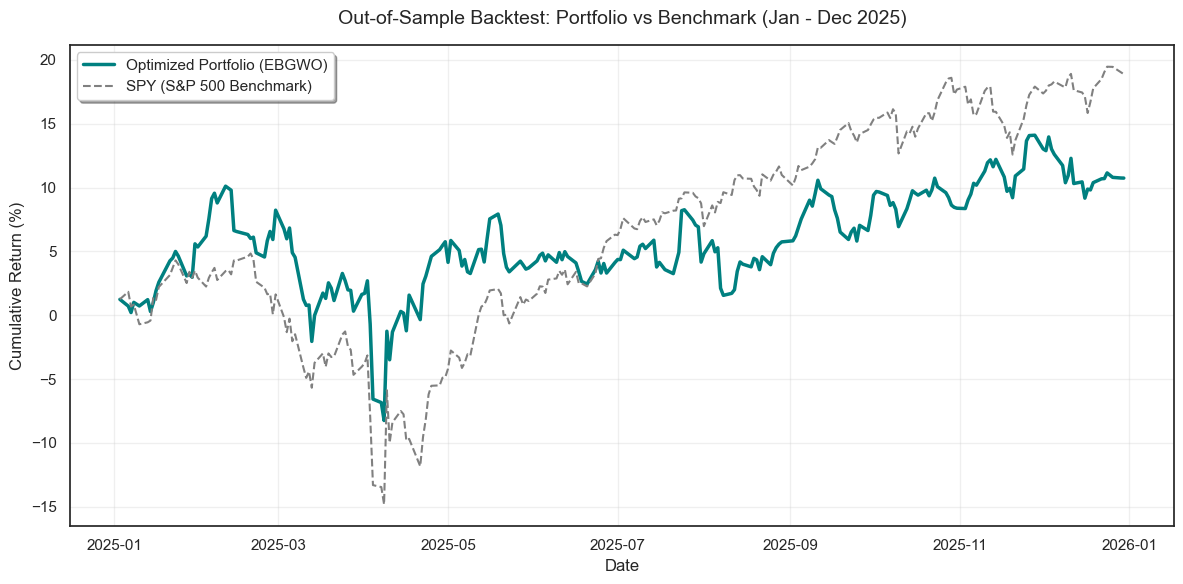

In [45]:
# ---------------------------------------------------------
# Step 9: Out-of-Sample Backtest (Jan 2025 - Dec 2025)
# ---------------------------------------------------------
print("\n--- Starting Phase 3: Out-of-Sample Backtesting ---")

# 1. กำหนดช่วงเวลาทดสอบและดึงข้อมูล Out-of-Sample
start_date_test = '2025-01-01'
end_date_test = '2025-12-31'

print(f"Downloading testing data from {start_date_test} to {end_date_test}...")

# ดึงข้อมูลหุ้นที่ถูกคัดเลือกและกองทุน SPY เพื่อใช้เป็น Benchmark
tickers_to_download = selected_stocks + ['SPY']
test_data = yf.download(tickers_to_download, start=start_date_test, end=end_date_test)['Close']

# จัดการ Missing Data ในช่วงทดสอบ
test_data = test_data.ffill().bfill()

# 2. คำนวณผลตอบแทนรายวัน (Normal / Simple Returns)
test_returns = test_data.pct_change().dropna()

# แยกข้อมูลผลตอบแทนของพอร์ตโฟลิโอและ Benchmark (SPY) 
# พร้อมทั้งจัดเรียงคอลัมน์ให้ตรงกับลำดับของ selected_stocks เพื่อจับคู่น้ำหนักให้ถูกต้อง
port_test_returns = test_returns[selected_stocks]
spy_test_returns = test_returns['SPY']

# 3. จำลองพอร์ตโฟลิโอโดยใช้น้ำหนักที่คงที่จาก EBGWO
# (นำผลตอบแทนของหุ้นแต่ละตัวมาคูณกับน้ำหนัก best_weights_global และรวมเป็นผลตอบแทนรายวันของพอร์ต)
daily_portfolio_returns = (port_test_returns * best_weights_global).sum(axis=1)

# 4. คำนวณ Cumulative Returns
cumulative_port_returns = (1 + daily_portfolio_returns).cumprod() - 1
cumulative_spy_returns = (1 + spy_test_returns).cumprod() - 1

# 5. คำนวณ Metrics เชิงประสิทธิภาพ (Performance Metrics)
# --- สำหรับ Optimized Portfolio ---
test_ann_return = daily_portfolio_returns.mean() * 252
test_ann_vol = daily_portfolio_returns.std() * np.sqrt(252)
test_sharpe = test_ann_return / test_ann_vol if test_ann_vol > 0 else 0

rolling_max_port = (1 + cumulative_port_returns).cummax()
drawdown_port = (1 + cumulative_port_returns) / rolling_max_port - 1
max_dd_port = drawdown_port.min()

# --- สำหรับ SPY (Benchmark) ---
spy_ann_return = spy_test_returns.mean() * 252
spy_ann_vol = spy_test_returns.std() * np.sqrt(252)
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

rolling_max_spy = (1 + cumulative_spy_returns).cummax()
drawdown_spy = (1 + cumulative_spy_returns) / rolling_max_spy - 1
max_dd_spy = drawdown_spy.min()

# 6. แสดงตารางสรุปผลลัพธ์ Backtest
print("\n=== Backtest Results (Jan 1, 2025 - Dec 31, 2025) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)':<20}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {cumulative_port_returns.iloc[-1]:.2%} {'':<13} | {cumulative_spy_returns.iloc[-1]:.2%}")
print(f"{'Annualized Return':<22} | {test_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {test_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {test_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {max_dd_port:.2%} {'':<13} | {max_dd_spy:.2%}")
print("-" * 68)

# 7. พล็อตกราฟ Equity Curve เปรียบเทียบ
plt.figure(figsize=(12, 6))

plt.plot(cumulative_port_returns.index, cumulative_port_returns * 100, 
         label='Optimized Portfolio (EBGWO)', color='teal', linewidth=2.5)

plt.plot(cumulative_spy_returns.index, cumulative_spy_returns * 100, 
         label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

plt.title('Out-of-Sample Backtest: Portfolio vs Benchmark (Jan - Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# แสดงผลกราฟ
plt.show()


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4022. Starting rolling window process...
Rebalanced for trading period: 2013-01-07 to 2013-04-08
Rebalanced for trading period: 2013-04-09 to 2013-07-08
Rebalanced for trading period: 2013-07-09 to 2013-10-04
Rebalanced for trading period: 2013-10-07 to 2014-01-06
Rebalanced for trading period: 2014-01-07 to 2014-04-07
Rebalanced for trading period: 2014-04-08 to 2014-07-08
Rebalanced for trading period: 2014-07-09 to 2014-10-06
Rebalanced for trading period: 2014-10-07 to 2015-01-06
Rebalanced for trading period: 2015-01-07 to 2015-04-08
Rebalanced for trading period: 2015-04-09 to 2015-07-08
Rebalanced for trading period: 2015-07-09 to 2015-10-06
Rebalanced for trading period: 2015-10-07 to 2016-01-06
Rebalanced for trading period: 2016-01-07 to 2016-04-07
Rebalanced for trading period: 2016-04-08 to 2016-07-07
Rebalanced for trading period: 2016-07-08 to 2016-10-05
Rebalanced for trading period: 2016-10-06 to 2017-01-05
Rebalanced for trading period: 2017-01-06 t

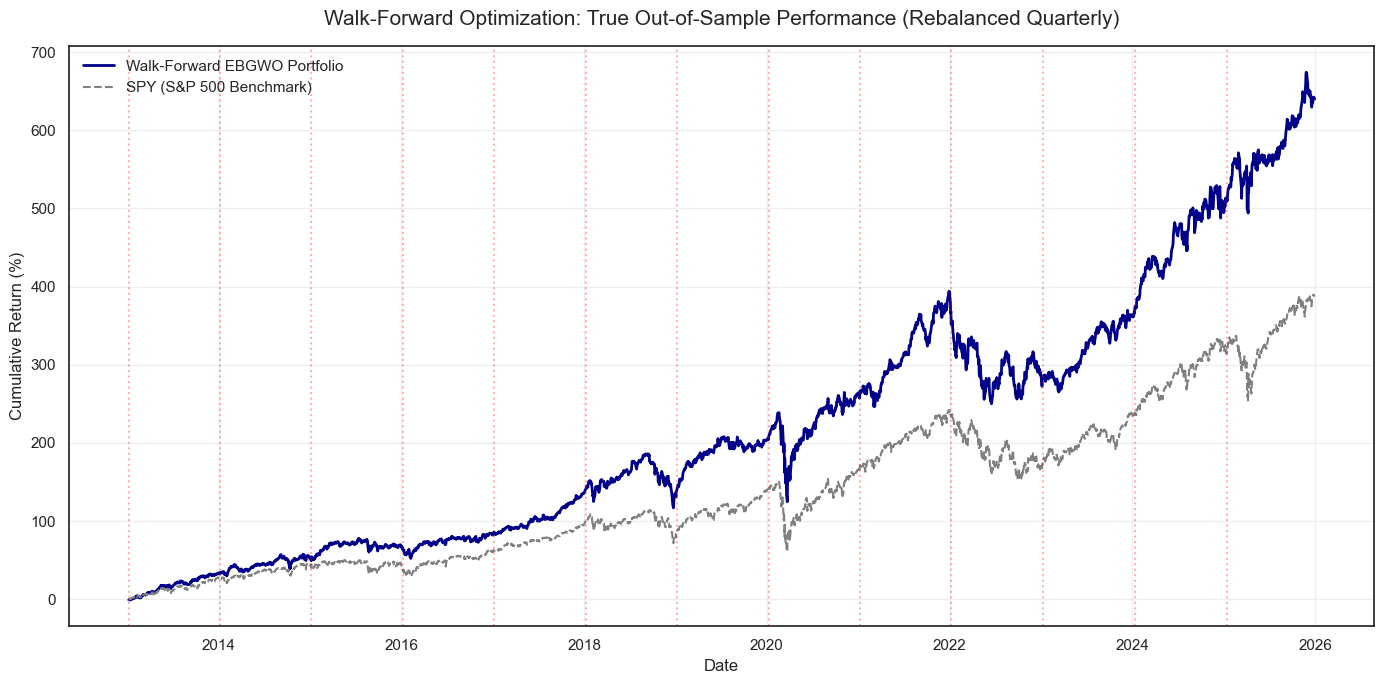


=== Walk-Forward Performance Metrics ===
Annualized Return:      16.84%
Annualized Volatility:  16.66%
Sharpe Ratio:           1.0107

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 640.15%               | 387.27%
Annualized Return      | 16.84%               | 13.67%
Annualized Volatility  | 16.66%               | 16.96%
Sharpe Ratio           | 1.0107                | 0.8057
Max Drawdown           | -33.62%               | -35.75%
--------------------------------------------------------------------


In [68]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]

def optimize_weights_ebgwo_monte_carlo(train_returns_gpu, max_weight=0.20, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization ร่วมกับ Monte Carlo (Historical Bootstrapping)
    (ใช้ Sharpe Ratio เป็น Objective Function)
    """
    num_days, num_assets = train_returns_gpu.shape
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    ST = 0.6
    
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=train_returns_gpu.device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -np.inf
    
    for iteration in range(iterations):
        
        # ========================================================
        # [ส่วนที่เพิ่มเข้ามา] MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        # สุ่มดึง Index ของวันแบบใส่คืน (With Replacement) เพื่อสร้างตลาดจำลอง
        mc_indices = torch.randint(0, num_days, (num_days,), device=train_returns_gpu.device)
        
        # สร้างผลตอบแทนจำลองจาก Index ที่สุ่มได้
        mc_returns = train_returns_gpu[mc_indices]
        # ========================================================
        
        # 1. คำนวณ Portfolio Returns จาก **ตลาดจำลอง (mc_returns)** แทนของจริง
        portfolio_returns = torch.matmul(mc_returns, wolves.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        
        # [แก้ไข] คำนวณ Total Volatility (Standard Deviation รวม) สำหรับ Sharpe Ratio
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sharpe Ratio และ Penalty
        sharpe_ratios = torch.where(port_ann_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_ann_vol, torch.zeros_like(port_ann_return))
        
        # ใช้ Penalty เพื่อจำกัดไม่ให้น้ำหนักของหุ้นตัวใดตัวหนึ่งเกิน max_weight
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # Fitness ในรอบนี้คือ Sharpe Ratio ที่ถูกหักลบด้วย Penalty
        fitnesses = sharpe_ratios - weight_penalties
        
        # 3. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 4. อัปเดตตำแหน่งหมาป่า (EBGWO Core Mechanics)
        a = 2.0 - iteration * (2.0 / iterations)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        exploration_mask = torch.rand((num_wolves, 1), device=train_returns_gpu.device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global


print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start='2010-01-01', end='2025-12-31')['Close']
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()

# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    best_weights = optimize_weights_ebgwo_monte_carlo(train_returns, max_weight=0.15, num_wolves=500, iterations=1000)
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4022. Starting rolling window process...
Rebalanced for trading period: 2013-01-07 to 2013-04-08
Rebalanced for trading period: 2013-04-09 to 2013-07-08
Rebalanced for trading period: 2013-07-09 to 2013-10-04
Rebalanced for trading period: 2013-10-07 to 2014-01-06
Rebalanced for trading period: 2014-01-07 to 2014-04-07
Rebalanced for trading period: 2014-04-08 to 2014-07-08
Rebalanced for trading period: 2014-07-09 to 2014-10-06
Rebalanced for trading period: 2014-10-07 to 2015-01-06
Rebalanced for trading period: 2015-01-07 to 2015-04-08
Rebalanced for trading period: 2015-04-09 to 2015-07-08
Rebalanced for trading period: 2015-07-09 to 2015-10-06
Rebalanced for trading period: 2015-10-07 to 2016-01-06
Rebalanced for trading period: 2016-01-07 to 2016-04-07
Rebalanced for trading period: 2016-04-08 to 2016-07-07
Rebalanced for trading period: 2016-07-08 to 2016-10-05
Rebalanced for trading period: 2016-10-06 to 2017-01-05
Rebalanced for trading period: 2017-01-06 t

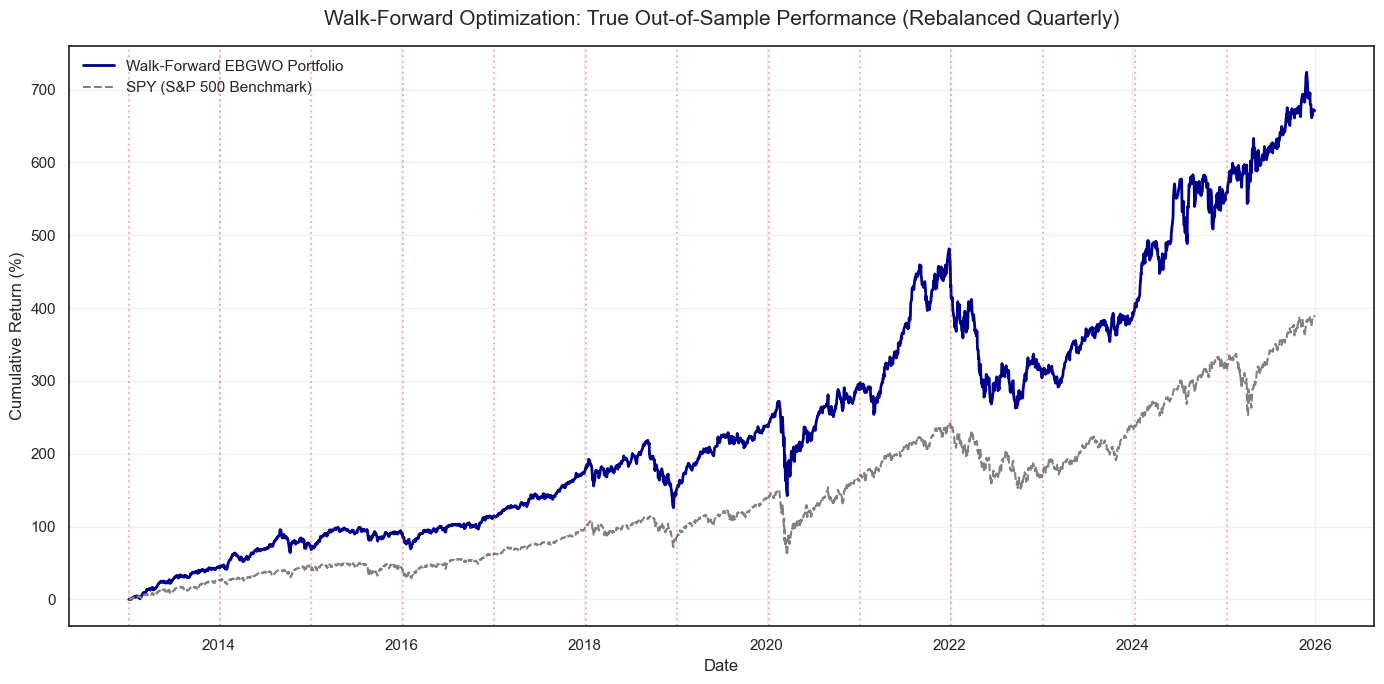


=== Walk-Forward Performance Metrics ===
Annualized Return:      17.43%
Annualized Volatility:  18.20%
Sharpe Ratio:           0.9574

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 670.96%               | 387.27%
Annualized Return      | 17.43%               | 13.67%
Annualized Volatility  | 18.20%               | 16.96%
Sharpe Ratio           | 0.9574                | 0.8057
Max Drawdown           | -37.63%               | -35.75%
--------------------------------------------------------------------


In [72]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]
def calculate_fitness_er_ga(wolves, returns_gpu, lambda_ent=0.1, risk_free_rate=0.0434):
    """
    คำนวณ Fitness ด้วย Entropy-Regularised Sharpe Ratio
    """
    n_assets = wolves.shape[1]
    sqrt_252 = math.sqrt(252)
    eps = 1e-10 # ป้องกัน log(0)
    
    # 1. คำนวณ Sharpe Ratio
    portfolio_returns = torch.matmul(returns_gpu, wolves.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    sharpe_ratios = torch.where(port_ann_vol > 0, (port_ann_return - risk_free_rate) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. คำนวณ Normalised Entropy: H(w) / log(n)
    # entropy = -sum(w * log(w))
    entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
    norm_entropy = entropy / math.log(n_assets)
    
    # 3. รวม Objective
    fitness = sharpe_ratios + (lambda_ent * norm_entropy)
    return fitness

def optimize_weights_er_ga(train_returns_gpu, lambda_ent=0.05, pop_size=500, generations=1000, mutation_rate=0.1):
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device

    # 1. Initialization (สร้างประชากรเริ่มต้น)
    pop = torch.rand((pop_size, num_assets), device=device)
    pop = pop / pop.sum(dim=1, keepdim=True)

    best_fitness_global = -float('inf')
    best_weights_global = None

    for gen in range(generations):
        # Evaluation
        fitness = calculate_fitness_er_ga(pop, train_returns_gpu, lambda_ent)
        
        # เก็บตัวที่ดีที่สุด (Elitism)
        max_fit, max_idx = torch.max(fitness, dim=0)
        if max_fit > best_fitness_global:
            best_fitness_global = max_fit.item()
            best_weights_global = pop[max_idx].clone()

        # Selection (Tournament Selection)
        # สุ่มสู้กัน 2 ตัว ใครชนะได้เป็นพ่อแม่
        idx1 = torch.randint(0, pop_size, (pop_size,), device=device)
        idx2 = torch.randint(0, pop_size, (pop_size,), device=device)
        parents = torch.where(fitness[idx1].unsqueeze(1) > fitness[idx2].unsqueeze(1), pop[idx1], pop[idx2])

        # Crossover (Arithmetic Crossover)
        # ผสมน้ำหนักระหว่างพ่อและแม่
        alpha = torch.rand((pop_size, 1), device=device)
        offspring = alpha * parents + (1 - alpha) * parents[torch.randperm(pop_size)]

        # Mutation
        # สุ่มเปลี่ยนน้ำหนักบางส่วน
        mutation_mask = torch.rand((pop_size, num_assets), device=device) < mutation_rate
        noise = torch.rand((pop_size, num_assets), device=device) * mutation_mask
        offspring = offspring + noise

        # Constraints: Re-normalize ให้รวมกันได้ 1 และไม่ติดลบ
        offspring = torch.clamp(offspring, min=0.0)
        pop = offspring / offspring.sum(dim=1, keepdim=True)
        
        # ใส่ Elitism กลับเข้าไปในประชากร (ตัวที่ดีที่สุดไม่หายไป)
        pop[0] = best_weights_global

    return best_weights_global.cpu().numpy()


print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start='2010-01-01', end='2025-12-31')['Close']
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()

# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    best_weights = best_weights = optimize_weights_er_ga(
    train_returns, 
    lambda_ent=0.05,  # ค่าความแรงของ Entropy (ยิ่งมากยิ่งกระจายหุ้น)
    pop_size=500, 
    generations=1000)
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)

Ticker,AJG,APH,AVGO,AWK,BKNG,BRK-B,CDNS,CHD,CHTR,COR,...,NVR,ODFL,ORLY,ROP,SBAC,SPY,SW,TPL,UNH,WST
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,-0.005389,-0.021118,0.007396,0.010103,0.011542,0.004821,-0.009852,-0.013623,0.000000,-0.007161,...,0.003264,0.021281,0.001557,-0.012834,0.023603,0.002644,0.000000,0.055097,-0.001588,-0.012749
2010-01-06,0.000451,0.003772,0.007863,0.005232,-0.033573,-0.005123,0.011485,0.004781,0.000000,-0.009500,...,0.003086,0.018215,-0.004419,0.009515,-0.001946,0.000704,0.000000,-0.025668,0.009800,-0.009799
2010-01-07,-0.006320,-0.006667,-0.006286,0.002171,-0.013557,0.003920,0.019387,-0.011247,0.000000,-0.016166,...,0.018361,-0.049446,-0.003131,-0.003834,0.014091,0.004212,0.000000,-0.008368,0.037659,0.003105
2010-01-08,0.002713,0.007331,0.007330,-0.002171,0.000370,-0.000301,0.014297,-0.002164,-0.043803,0.010806,...,-0.007571,0.013699,-0.008924,0.007081,0.001097,0.003322,0.000000,-0.025534,-0.009435,-0.000258
2010-01-11,0.001354,0.002431,0.006240,0.009951,0.012410,0.000903,0.000000,-0.004344,0.000000,0.011071,...,-0.021034,-0.005799,0.005259,0.004186,0.006828,0.001396,0.000000,-0.002763,0.006705,-0.004403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.001741,0.014545,0.022787,-0.007012,0.005952,0.001119,-0.002017,0.011918,-0.003598,0.001646,...,-0.008011,-0.004278,0.003482,0.000200,0.006692,0.004560,0.003930,-0.018230,-0.001108,0.009414
2025-12-24,0.007970,0.005962,0.002573,0.004045,0.001330,0.001657,0.002616,0.002460,0.015372,-0.001793,...,0.006417,0.004654,0.003578,0.004087,0.003589,0.003511,-0.002881,-0.004483,0.008523,-0.002996
2025-12-26,0.002719,-0.003704,0.005439,-0.005576,-0.001170,-0.006082,0.003550,-0.000819,-0.006256,0.003142,...,-0.000424,0.000815,-0.001625,-0.000776,0.000000,-0.000101,0.015871,-0.028997,0.012891,-0.008567



--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4022. Starting rolling window process...
Rebalanced for trading period: 2013-01-07 to 2013-04-08
Rebalanced for trading period: 2013-04-09 to 2013-07-08
Rebalanced for trading period: 2013-07-09 to 2013-10-04
Rebalanced for trading period: 2013-10-07 to 2014-01-06
Rebalanced for trading period: 2014-01-07 to 2014-04-07
Rebalanced for trading period: 2014-04-08 to 2014-07-08
Rebalanced for trading period: 2014-07-09 to 2014-10-06
Rebalanced for trading period: 2014-10-07 to 2015-01-06
Rebalanced for trading period: 2015-01-07 to 2015-04-08
Rebalanced for trading period: 2015-04-09 to 2015-07-08
Rebalanced for trading period: 2015-07-09 to 2015-10-06
Rebalanced for trading period: 2015-10-07 to 2016-01-06
Rebalanced for trading period: 2016-01-07 to 2016-04-07
Rebalanced for trading period: 2016-04-08 to 2016-07-07
Rebalanced for trading period: 2016-07-08 to 2016-10-05
Rebalanced for trading period: 2016-10-06 to 2017-01-05
Rebalanced for trading period: 2017-01-06 t

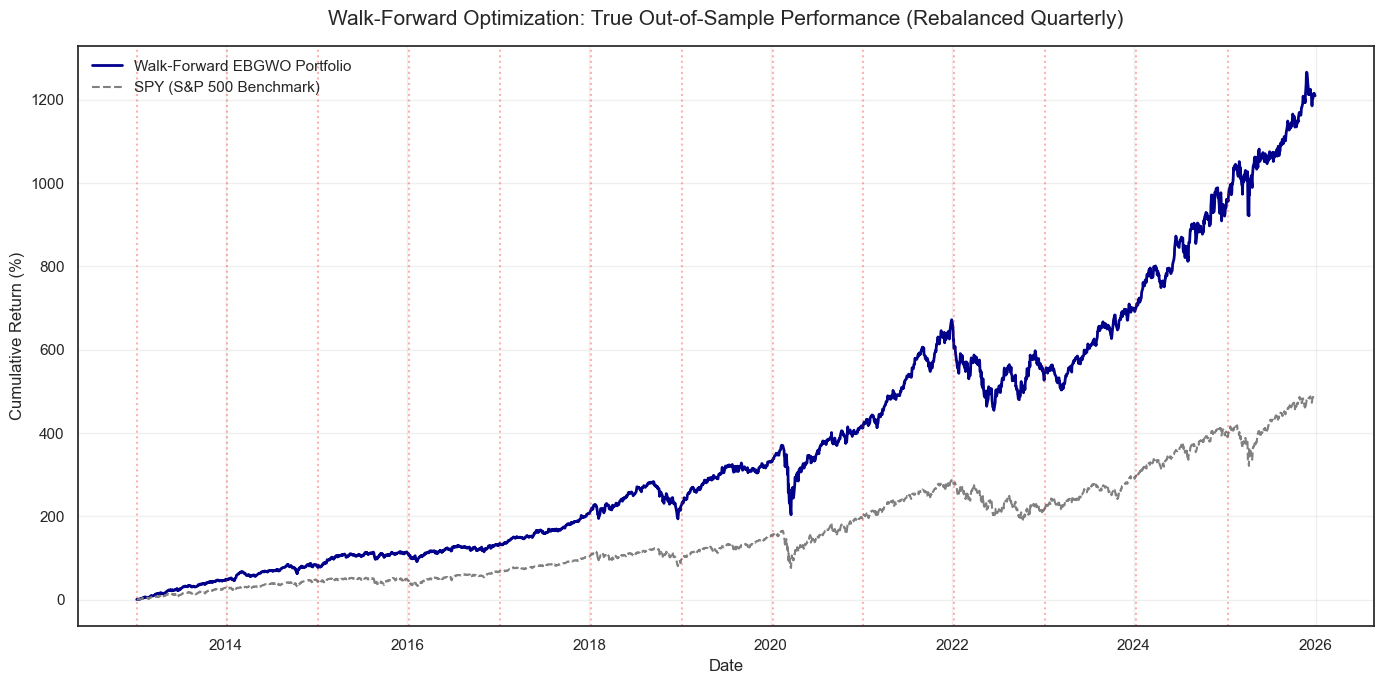


=== Walk-Forward Performance Metrics ===
Annualized Return:      21.25%
Annualized Volatility:  16.65%
Sharpe Ratio:           1.2760

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 1209.87%               | 487.91%
Annualized Return      | 21.25%               | 15.11%
Annualized Volatility  | 16.65%               | 16.93%
Sharpe Ratio           | 1.2760                | 0.8925
Max Drawdown           | -35.46%               | -33.72%
--------------------------------------------------------------------


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]
def calculate_fitness_er_ga(wolves, returns_gpu, lambda_ent=0.1, risk_free_rate=0.0434):
    """
    คำนวณ Fitness ด้วย Entropy-Regularised Sharpe Ratio
    """
    n_assets = wolves.shape[1]
    sqrt_252 = math.sqrt(252)
    eps = 1e-10 # ป้องกัน log(0)
    
    # 1. คำนวณ Sharpe Ratio
    portfolio_returns = torch.matmul(returns_gpu, wolves.T)
    port_ann_return = portfolio_returns.mean(dim=0) * 252
    port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
    sharpe_ratios = torch.where(port_ann_vol > 0, (port_ann_return - risk_free_rate) / port_ann_vol, torch.zeros_like(port_ann_return))
    
    # 2. คำนวณ Normalised Entropy: H(w) / log(n)
    # entropy = -sum(w * log(w))
    entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
    norm_entropy = entropy / math.log(n_assets)
    
    # 3. รวม Objective
    fitness = sharpe_ratios + (lambda_ent * norm_entropy)
    return fitness

def optimize_weights_ebgwo_monte_carlo_entropy(train_returns_gpu, max_weight=0.15, lambda_ent=0.05, num_wolves=500, iterations=1000):
    """
    EBGWO Optimization + Monte Carlo + Entropy Regularization
    Objective: Maximize [Sharpe Ratio + lambda_ent * Normalized_Entropy]
    """
    num_days, num_assets = train_returns_gpu.shape
    device = train_returns_gpu.device
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    log_n = math.log(num_assets)
    ST = 0.2
    eps = 1e-10  # ป้องกัน log(0)
    
    # 1. Initialize Wolves (Population)
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -float('inf')
    
    for iteration in range(iterations):
        
        # ========================================================
        # MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        mc_indices = torch.randint(0, num_days, (num_days,), device=device)
        mc_returns = train_returns_gpu[mc_indices]
        
        # 1. คำนวณ Portfolio Performance
        portfolio_returns = torch.matmul(mc_returns, wolves.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        port_ann_vol = portfolio_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sharpe Ratio
        sharpe_ratios = torch.where(port_ann_vol > 0, 
                                    (port_ann_return - RISK_FREE_RATE) / port_ann_vol, 
                                    torch.zeros_like(port_ann_return))
        
        # 3. [NEW] คำนวณ Normalised Entropy (H(w) / log(n))
        # Formula: -sum(w * log(w))
        entropy = -torch.sum(wolves * torch.log(wolves + eps), dim=1)
        norm_entropy = entropy / log_n
        
        # 4. คำนวณ Penalty (จำกัด max_weight)
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # ========================================================
        # TOTAL FITNESS = Sharpe + (lambda * Entropy) - Penalty
        # ========================================================
        fitnesses = sharpe_ratios + (lambda_ent * norm_entropy) - weight_penalties
        
        # 5. คัดเลือก Alpha, Beta, Delta (Top 3)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # อัปเดต Global Best
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 6. อัปเดตตำแหน่งหมาป่า (EBGWO Core)
        a = 2.0 - iteration * (2.0 / iterations)
        
        # Vectorized Update for X1, X2, X3
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        exploration_mask = torch.rand((num_wolves, 1), device=device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global



print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start='2010-01-01', end='2025-12-31')['Close']
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()
# full_returns =  full_data.pct_change().dropna()
# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]
all_weights_history = []  # <--- เพิ่มตัวแปรนี้เพื่อแก้ Error
out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    # ใน Loop Walk-Forward
    best_weights = optimize_weights_ebgwo_monte_carlo_entropy(
        train_returns, 
        max_weight=0.15, 
        lambda_ent=0.05,  # ปรับเพิ่มถ้าอยากให้พอร์ตกระจายหุ้นมากขึ้น
        num_wolves=500, 
        iterations=1000
    )
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    all_weights_history.append(best_weights)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)


--- Starting Phase 3: Walk-Forward Optimization ---


[*********************100%***********************]  31 of 31 completed


Total trading days: 4022. Starting rolling window process...
Rebalanced for trading period: 2013-01-07 to 2013-04-08
Rebalanced for trading period: 2013-04-09 to 2013-07-08
Rebalanced for trading period: 2013-07-09 to 2013-10-04
Rebalanced for trading period: 2013-10-07 to 2014-01-06
Rebalanced for trading period: 2014-01-07 to 2014-04-07
Rebalanced for trading period: 2014-04-08 to 2014-07-08
Rebalanced for trading period: 2014-07-09 to 2014-10-06
Rebalanced for trading period: 2014-10-07 to 2015-01-06
Rebalanced for trading period: 2015-01-07 to 2015-04-08
Rebalanced for trading period: 2015-04-09 to 2015-07-08
Rebalanced for trading period: 2015-07-09 to 2015-10-06
Rebalanced for trading period: 2015-10-07 to 2016-01-06
Rebalanced for trading period: 2016-01-07 to 2016-04-07
Rebalanced for trading period: 2016-04-08 to 2016-07-07
Rebalanced for trading period: 2016-07-08 to 2016-10-05
Rebalanced for trading period: 2016-10-06 to 2017-01-05
Rebalanced for trading period: 2017-01-06 t

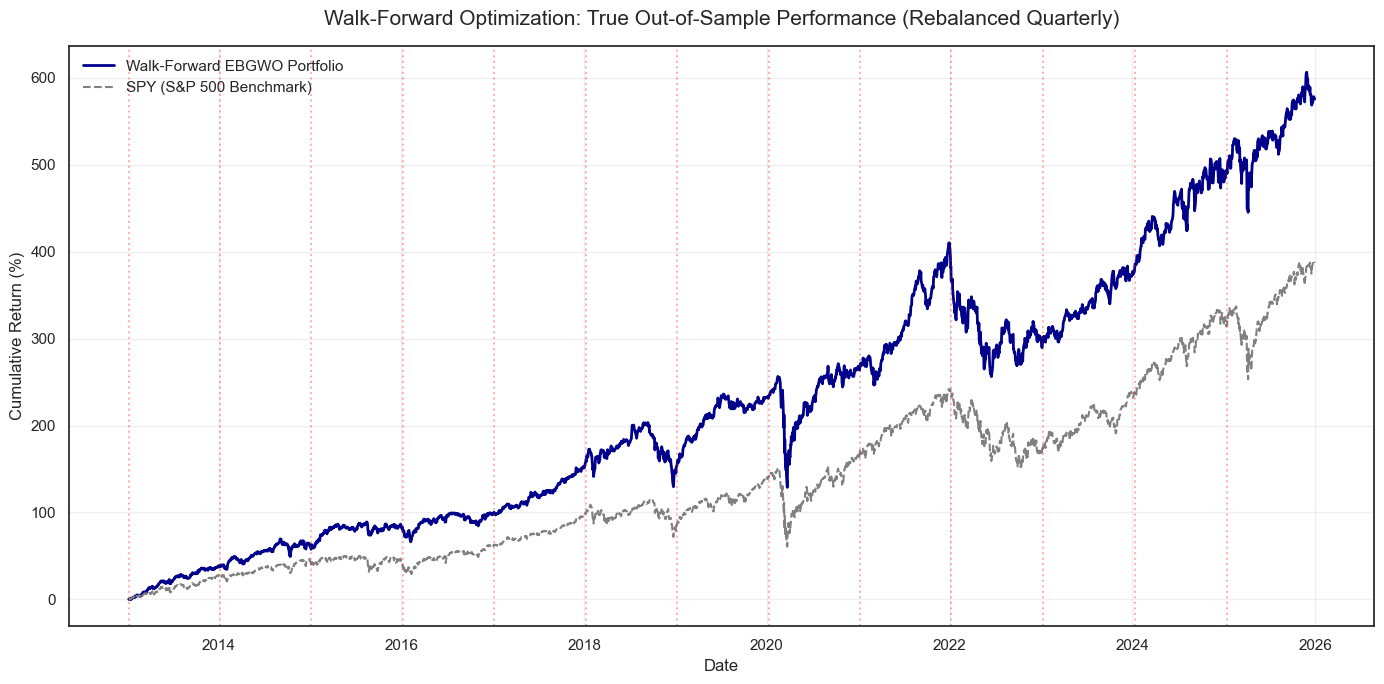


=== Walk-Forward Performance Metrics ===
Annualized Return:      16.10%
Annualized Volatility:  16.44%
Sharpe Ratio:           0.9796

=== Walk-Forward Performance Metrics ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 575.68%               | 387.27%
Annualized Return      | 16.10%               | 13.67%
Annualized Volatility  | 16.44%               | 16.96%
Sharpe Ratio           | 0.9796                | 0.8057
Max Drawdown           | -35.79%               | -35.75%
--------------------------------------------------------------------


In [53]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import yfinance as yf

# สมมติว่า valid_tickers และ selected_stocks ถูกกำหนดไว้แล้วจากขั้นตอนก่อนหน้า
# selected_indices = [list(valid_tickers).index(stock) for stock in selected_stocks]

def optimize_weights_ebgwo_monte_carlo(train_returns_gpu, max_weight=0.15, num_wolves=300, iterations=300):
    """
    EBGWO Optimization ร่วมกับ Monte Carlo (Historical Bootstrapping)
    """
    num_days, num_assets = train_returns_gpu.shape
    RISK_FREE_RATE = 0.0434
    sqrt_252 = math.sqrt(252)
    ST = 0.6
    
    wolves = torch.rand((num_wolves, num_assets), dtype=torch.float32, device=train_returns_gpu.device)
    wolves = wolves / wolves.sum(dim=1, keepdim=True)
    
    best_weights_global = None
    best_fitness_global = -np.inf
    
    for iteration in range(iterations):
        
        # ========================================================
        # [ส่วนที่เพิ่มเข้ามา] MONTE CARLO SIMULATION (Bootstrapping)
        # ========================================================
        # สุ่มดึง Index ของวันแบบใส่คืน (With Replacement) เพื่อสร้างตลาดจำลอง
        mc_indices = torch.randint(0, num_days, (num_days,), device=train_returns_gpu.device)
        
        # สร้างผลตอบแทนจำลองจาก Index ที่สุ่มได้
        mc_returns = train_returns_gpu[mc_indices]
        # ========================================================
        
        # 1. คำนวณ Portfolio Returns จาก **ตลาดจำลอง (mc_returns)** แทนของจริง
        portfolio_returns = torch.matmul(mc_returns, wolves.T)
        port_ann_return = portfolio_returns.mean(dim=0) * 252
        
        downside_returns = torch.where(portfolio_returns < 0, portfolio_returns, torch.zeros_like(portfolio_returns))
        port_downside_vol = downside_returns.std(dim=0, unbiased=True) * sqrt_252
        
        # 2. คำนวณ Sortino Ratio และ Penalty
        sortino_ratios = torch.where(port_downside_vol > 0, (port_ann_return - RISK_FREE_RATE) / port_downside_vol, torch.zeros_like(port_ann_return))
        weight_penalties = torch.sum(torch.relu(wolves - max_weight), dim=1) * 100.0
        
        # Fitness ในรอบนี้คือความสามารถในการเอาตัวรอดใน "ตลาดจำลอง (Monte Carlo)"
        fitnesses = sortino_ratios - weight_penalties
        
        # 3. คัดเลือก Alpha, Beta, Delta (ใช้กระบวนการเดิม)
        sorted_indices = torch.argsort(fitnesses, descending=True)
        alpha_pos = wolves[sorted_indices[0]].clone()
        beta_pos = wolves[sorted_indices[1]].clone()
        delta_pos = wolves[sorted_indices[2]].clone()
        alpha_fitness = fitnesses[sorted_indices[0]].item()
        
        # สำคัญ: อัปเดต Global Best ต่อเมื่อมันทนทานต่อสภาวะจำลองได้ดีจริงๆ
        if alpha_fitness > best_fitness_global:
            best_fitness_global = alpha_fitness
            best_weights_global = alpha_pos.cpu().numpy()
            
        # 4. อัปเดตตำแหน่งหมาป่า (EBGWO Core Mechanics)
        a = 2.0 - iteration * (2.0 / iterations)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A1, C1 = 2 * a * r1 - a, 2 * r2
        X1 = alpha_pos - A1 * torch.abs(C1 * alpha_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A2, C2 = 2 * a * r1 - a, 2 * r2
        X2 = beta_pos - A2 * torch.abs(C2 * beta_pos - wolves)
        
        r1, r2 = torch.rand_like(wolves), torch.rand_like(wolves)
        A3, C3 = 2 * a * r1 - a, 2 * r2
        exploration_mask = torch.rand((num_wolves, 1), device=train_returns_gpu.device) < ST
        random_wolves = wolves[torch.randint(0, num_wolves, (num_wolves,))]
        delta_or_random_pos = torch.where(exploration_mask, random_wolves, delta_pos)
        X3 = delta_or_random_pos - A3 * torch.abs(C3 * delta_or_random_pos - wolves)
        
        new_wolves = (X1 + X2 + X3) / 3.0
        new_wolves = torch.clamp(new_wolves, 0.0, 1.0)
        sums = new_wolves.sum(dim=1, keepdim=True)
        wolves = torch.where(sums > 0, new_wolves / sums, wolves)
        
    return best_weights_global

print("\n--- Starting Phase 3: Walk-Forward Optimization ---")


# ดึงข้อมูลทั้งหมดตั้งแต่ต้นจนถึงปัจจุบันเพื่อทำ Walk-Forward (รวมข้อมูลที่ยังไม่เห็นด้วย)
all_tickers = selected_stocks + ['SPY']
print(f"Downloading full dataset for Walk-Forward...")
full_data = yf.download(all_tickers, start='2010-01-01', end='2025-12-31')['Close']
full_data = full_data.ffill().bfill()

# คำนวณ Log Returns
full_returns = np.log(full_data / full_data.shift(1)).dropna()

# แยกข้อมูล
port_full_returns = full_returns[selected_stocks]
spy_full_returns = full_returns['SPY']

# ย้ายข้อมูลหุ้นที่เลือกไปบน GPU
returns_gpu_full = torch.tensor(port_full_returns.values, dtype=torch.float32, device=device)

# --- ตั้งค่าตัวแปร Walk-Forward ---
LOOKBACK_WINDOW = 252 * 3  # ใช้ข้อมูลย้อนหลัง 3 ปี (756 วัน) ในการ Train
STEP_SIZE = 21*3             # เทรด (Out-of-sample) 3 เดือน (63 วัน) แล้วค่อย Rebalance ใหม่
total_days = returns_gpu_full.shape[0]

out_of_sample_port_returns = []
out_of_sample_spy_returns = []
rebalance_dates = []

print(f"Total trading days: {total_days}. Starting rolling window process...")

# ลูปเพื่อสไลด์หน้าต่างเวลา
for start_idx in range(0, total_days - LOOKBACK_WINDOW, STEP_SIZE):
    train_end = start_idx + LOOKBACK_WINDOW
    test_end = min(train_end + STEP_SIZE, total_days)
    
    # ดึงวันที่ (เพื่อเอาไว้พิมพ์ดูเฉยๆ)
    trade_start_date = port_full_returns.index[train_end].strftime('%Y-%m-%d')
    trade_end_date = port_full_returns.index[test_end-1].strftime('%Y-%m-%d')
    
    # 1. ข้อมูล In-Sample (Train)
    train_returns = returns_gpu_full[start_idx:train_end]
    
    # 2. รัน EBGWO เพื่อหาน้ำหนัก (อาจใช้เวลาเล็กน้อยในแต่ละลูป)
    best_weights = optimize_weights_ebgwo_monte_carlo(train_returns, max_weight=0.15, num_wolves=300, iterations=300)
    
    # 3. ข้อมูล Out-of-Sample (Test) - ข้อมูลอนาคตที่โมเดลไม่เคยเห็นตอน Train
    test_returns_cpu = port_full_returns.iloc[train_end:test_end].values
    
    # คำนวณผลตอบแทนพอร์ตโฟลิโอในหน้าต่าง Out-of-Sample
    period_port_return = (test_returns_cpu * best_weights).sum(axis=1)
    period_spy_return = spy_full_returns.iloc[train_end:test_end].values
    
    # เก็บผลลัพธ์
    out_of_sample_port_returns.extend(period_port_return)
    out_of_sample_spy_returns.extend(period_spy_return)
    rebalance_dates.append(trade_start_date)
    
    print(f"Rebalanced for trading period: {trade_start_date} to {trade_end_date}")

# --- ประมวลผลและแสดงผลกราฟ Equity Curve แท้จริง (True Out-of-Sample) ---
# สร้าง Index วันที่ให้ตรงกับช่วงเวลาเทรดทั้งหมด (ตัด 3 ปีแรกของการ Train ทิ้งไป)
trade_dates = port_full_returns.index[LOOKBACK_WINDOW : LOOKBACK_WINDOW + len(out_of_sample_port_returns)]

# คำนวณ Cumulative Returns
cum_port_returns = np.cumprod(1 + np.array(out_of_sample_port_returns)) - 1
cum_spy_returns = np.cumprod(1 + np.array(out_of_sample_spy_returns)) - 1

# พล็อตกราฟเปรียบเทียบ
plt.figure(figsize=(14, 7))
plt.plot(trade_dates, cum_port_returns * 100, label='Walk-Forward EBGWO Portfolio', color='darkblue', linewidth=2)
plt.plot(trade_dates, cum_spy_returns * 100, label='SPY (S&P 500 Benchmark)', color='gray', linestyle='--', linewidth=1.5)

# เพิ่มเส้นประแนวตั้งเพื่อแสดงจังหวะการ Rebalance (ทุกๆ 1 ปี เพื่อไม่ให้รกเกินไป)
for i, date in enumerate(rebalance_dates):
    if i % 4 == 0: # 4 ไตรมาส = 1 ปี
        plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.3)

plt.title('Walk-Forward Optimization: True Out-of-Sample Performance (Rebalanced Quarterly)', fontsize=15, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- แสดง Metrics รวมของ Walk-Forward ---
wf_ann_return = np.mean(out_of_sample_port_returns) * 252
wf_ann_vol = np.std(out_of_sample_port_returns) * math.sqrt(252)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0

print("\n=== Walk-Forward Performance Metrics ===")
print(f"Annualized Return:      {wf_ann_return:.2%}")
print(f"Annualized Volatility:  {wf_ann_vol:.2%}")
print(f"Sharpe Ratio:           {wf_sharpe:.4f}")
# --- ประมวลผล Metrics สำหรับ Walk-Forward Portfolio และ SPY (Benchmark) ---

# แปลง list เป็น numpy array เพื่อการคำนวณที่ง่ายขึ้น
port_returns_arr = np.array(out_of_sample_port_returns)
spy_returns_arr = np.array(out_of_sample_spy_returns)

# 1. Cumulative Return
wf_cum_return = cum_port_returns[-1]
spy_cum_return = cum_spy_returns[-1]

# 2. Annualized Return
wf_ann_return = np.mean(port_returns_arr) * 252
spy_ann_return = np.mean(spy_returns_arr) * 252

# 3. Annualized Volatility
wf_ann_vol = np.std(port_returns_arr) * math.sqrt(252)
spy_ann_vol = np.std(spy_returns_arr) * math.sqrt(252)

# 4. Sharpe Ratio (ใช้ 0 Risk-Free rate เพื่อเปรียบเทียบเชิงสัมพัทธ์ตามปกติ)
wf_sharpe = wf_ann_return / wf_ann_vol if wf_ann_vol > 0 else 0
spy_sharpe = spy_ann_return / spy_ann_vol if spy_ann_vol > 0 else 0

# 5. Max Drawdown
# สำหรับ Portfolio
rolling_max_port = np.maximum.accumulate(1 + cum_port_returns)
drawdown_port = (1 + cum_port_returns) / rolling_max_port - 1
wf_max_dd = np.min(drawdown_port)

# สำหรับ SPY
rolling_max_spy = np.maximum.accumulate(1 + cum_spy_returns)
drawdown_spy = (1 + cum_spy_returns) / rolling_max_spy - 1
spy_max_dd = np.min(drawdown_spy)

# --- แสดงผลตารางแบบฟอร์แมต ---
print("\n=== Walk-Forward Performance Metrics ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return:.2%} {'':<13} | {spy_cum_return:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return:.2%} {'':<13} | {spy_ann_return:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol:.2%} {'':<13} | {spy_ann_vol:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe:.4f} {'':<14} | {spy_sharpe:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd:.2%} {'':<13} | {spy_max_dd:.2%}")
print("-" * 68)

DatetimeIndex(['2013-01-07', '2013-01-08', '2013-01-09', '2013-01-10',
               '2013-01-11', '2013-01-14', '2013-01-15', '2013-01-16',
               '2013-01-17', '2013-01-18',
               ...
               '2025-12-16', '2025-12-17', '2025-12-18', '2025-12-19',
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-26',
               '2025-12-29', '2025-12-30'],
              dtype='datetime64[s]', name='Date', length=3266, freq=None)


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 28.31%               | 18.60%
Annualized Return      | 26.75%               | 19.14%
Annualized Volatility  | 17.40%               | 19.47%
Sharpe Ratio           | 1.5374                | 0.9832
Max Drawdown           | -11.30%               | -18.76%
--------------------------------------------------------------------


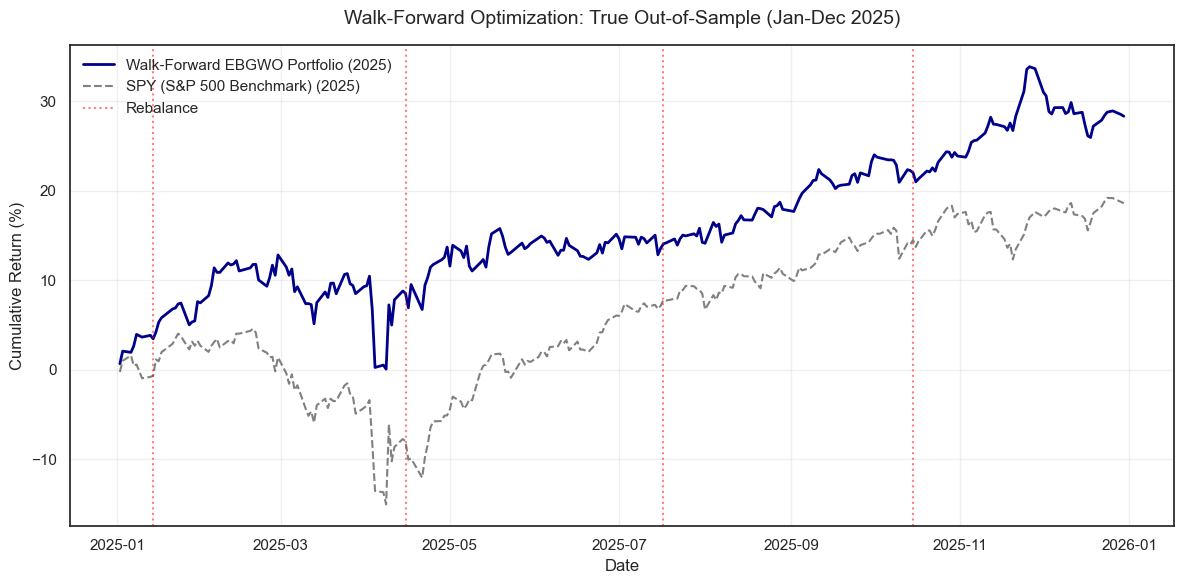

In [89]:
# --- กรองข้อมูลและประมวลผลเฉพาะปี 2025 ---

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

# ดึงวันที่และผลตอบแทนรายวันเฉพาะปี 2025
dates_2025 = trade_dates[mask_2025]
port_returns_2025 = np.array(out_of_sample_port_returns)[mask_2025]
spy_returns_2025 = np.array(out_of_sample_spy_returns)[mask_2025]

# 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ในวันที่ 1 ม.ค. 2025)
cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1

wf_cum_return_2025 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
spy_cum_return_2025 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0

# 2. Annualized Return สำหรับปี 2025
wf_ann_return_2025 = np.mean(port_returns_2025) * 252
spy_ann_return_2025 = np.mean(spy_returns_2025) * 252

# 3. Annualized Volatility สำหรับปี 2025
wf_ann_vol_2025 = np.std(port_returns_2025) * math.sqrt(252)
spy_ann_vol_2025 = np.std(spy_returns_2025) * math.sqrt(252)

# 4. Sharpe Ratio สำหรับปี 2025
wf_sharpe_2025 = wf_ann_return_2025 / wf_ann_vol_2025 if wf_ann_vol_2025 > 0 else 0
spy_sharpe_2025 = spy_ann_return_2025 / spy_ann_vol_2025 if spy_ann_vol_2025 > 0 else 0

# 5. Max Drawdown ภายในปี 2025
rolling_max_port_2025 = np.maximum.accumulate(1 + cum_port_2025)
drawdown_port_2025 = (1 + cum_port_2025) / rolling_max_port_2025 - 1
wf_max_dd_2025 = np.min(drawdown_port_2025) if len(drawdown_port_2025) > 0 else 0

rolling_max_spy_2025 = np.maximum.accumulate(1 + cum_spy_2025)
drawdown_spy_2025 = (1 + cum_spy_2025) / rolling_max_spy_2025 - 1
spy_max_dd_2025 = np.min(drawdown_spy_2025) if len(drawdown_spy_2025) > 0 else 0

# --- แสดงผลตารางแบบฟอร์แมต (เฉพาะปี 2025) ---
print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return_2025:.2%} {'':<13} | {spy_cum_return_2025:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return_2025:.2%} {'':<13} | {spy_ann_return_2025:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol_2025:.2%} {'':<13} | {spy_ann_vol_2025:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe_2025:.4f} {'':<14} | {spy_sharpe_2025:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd_2025:.2%} {'':<13} | {spy_max_dd_2025:.2%}")
print("-" * 68)

# --- พล็อตกราฟเฉพาะปี 2025 ---
plt.figure(figsize=(12, 6))
plt.plot(dates_2025, cum_port_2025 * 100, label='Walk-Forward EBGWO Portfolio (2025)', color='darkblue', linewidth=2)
plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark) (2025)', color='gray', linestyle='--', linewidth=1.5)

# กรอง Rebalance dates เฉพาะที่อยู่ในปี 2025 มาแสดงเป็นเส้นประ
rebalance_2025 = [date for date in rebalance_dates if date.startswith('2025')]
for date in rebalance_2025:
    plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.5, label='Rebalance' if date == rebalance_2025[0] else "")

plt.title('Walk-Forward Optimization: True Out-of-Sample (Jan-Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 1. จัดเตรียมข้อมูลน้ำหนักของแต่ละช่วงเวลา (Weight History) ---
# สร้าง DataFrame เพื่อเก็บประวัติน้ำหนักหุ้น
# df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)

# # กรองเฉพาะช่วงปี 2025
# df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# # --- 2. แสดงตารางน้ำหนักล่าสุด (Latest Weights in 2025) ---
# latest_weights = df_weight_2025.iloc[-1]
# latest_weights_df = pd.DataFrame({
#     'Ticker': latest_weights.index,
#     'Weight': latest_weights.values
# }).sort_values(by='Weight', ascending=False)

# print("\n=== Final Asset Weights (Latest Rebalance in 2025) ===")
# print(latest_weights_df.to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

# # --- 3. พล็อตกราฟการเปลี่ยนแปลงน้ำหนัก (Asset Weights Evolution) ---
# plt.figure(figsize=(14, 7))
# # ใช้ Stacked Area Chart เพื่อดูสัดส่วนรวมเป็น 100%
# plt.stackplot(pd.to_datetime(df_weight_2025.index), 
#               df_weight_2025.T, 
#               labels=df_weight_2025.columns,
#               alpha=0.8)

# plt.title('Asset Weights Evolution (Walk-Forward 2025)', fontsize=14, pad=15)
# plt.xlabel('Rebalance Date')
# plt.ylabel('Portfolio Allocation (%)')
# # ปรับ Legend ให้อยู่ด้านนอกถ้าหุ้นเยอะ
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize='small')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()


=== Walk-Forward Performance Metrics (Year 2025 Only) ===
Metric                 | Optimized Portfolio  | SPY (Benchmark)
--------------------------------------------------------------------
Cumulative Return      | 19.77%               | 16.44%
Annualized Return      | 19.84%               | 17.26%
Annualized Volatility  | 17.75%               | 19.31%
Sharpe Ratio           | 1.1176                | 0.8940
Max Drawdown           | -12.26%               | -19.21%
--------------------------------------------------------------------


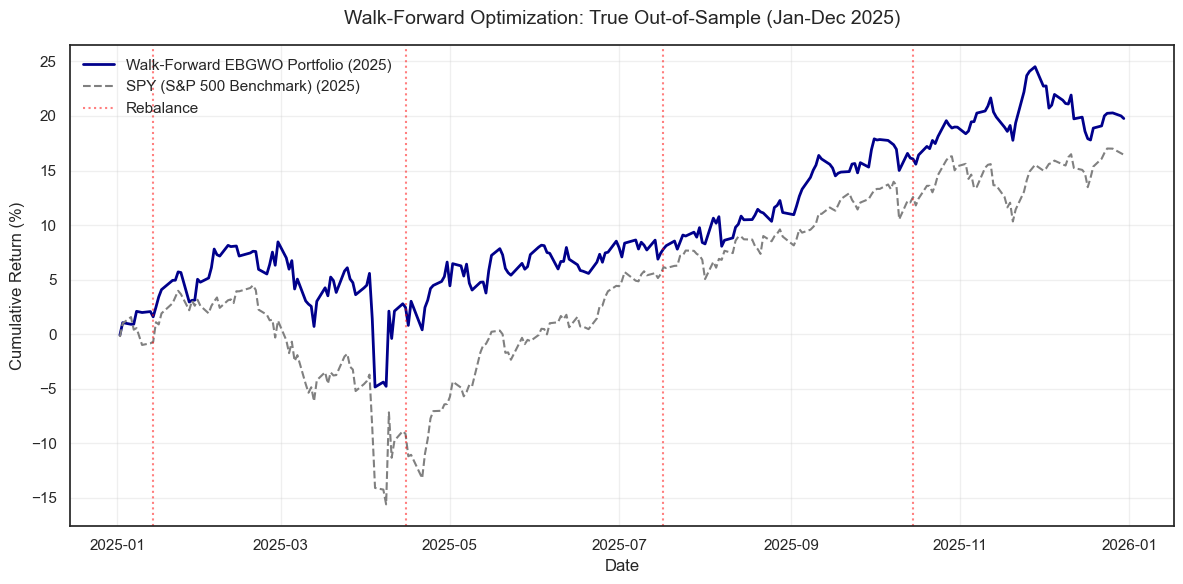

In [85]:
# --- กรองข้อมูลและประมวลผลเฉพาะปี 2025 ---

# สร้างเงื่อนไขเพื่อกรองเฉพาะวันที่อยู่ในปี 2025
mask_2025 = trade_dates.year == 2025

# ดึงวันที่และผลตอบแทนรายวันเฉพาะปี 2025
dates_2025 = trade_dates[mask_2025]
port_returns_2025 = np.array(out_of_sample_port_returns)[mask_2025]
spy_returns_2025 = np.array(out_of_sample_spy_returns)[mask_2025]

# 1. คำนวณ Cumulative Return (เริ่มนับ 0 ใหม่ในวันที่ 1 ม.ค. 2025)
cum_port_2025 = np.cumprod(1 + port_returns_2025) - 1
cum_spy_2025 = np.cumprod(1 + spy_returns_2025) - 1

wf_cum_return_2025 = cum_port_2025[-1] if len(cum_port_2025) > 0 else 0
spy_cum_return_2025 = cum_spy_2025[-1] if len(cum_spy_2025) > 0 else 0

# 2. Annualized Return สำหรับปี 2025
wf_ann_return_2025 = np.mean(port_returns_2025) * 252
spy_ann_return_2025 = np.mean(spy_returns_2025) * 252

# 3. Annualized Volatility สำหรับปี 2025
wf_ann_vol_2025 = np.std(port_returns_2025) * math.sqrt(252)
spy_ann_vol_2025 = np.std(spy_returns_2025) * math.sqrt(252)

# 4. Sharpe Ratio สำหรับปี 2025
wf_sharpe_2025 = wf_ann_return_2025 / wf_ann_vol_2025 if wf_ann_vol_2025 > 0 else 0
spy_sharpe_2025 = spy_ann_return_2025 / spy_ann_vol_2025 if spy_ann_vol_2025 > 0 else 0

# 5. Max Drawdown ภายในปี 2025
rolling_max_port_2025 = np.maximum.accumulate(1 + cum_port_2025)
drawdown_port_2025 = (1 + cum_port_2025) / rolling_max_port_2025 - 1
wf_max_dd_2025 = np.min(drawdown_port_2025) if len(drawdown_port_2025) > 0 else 0

rolling_max_spy_2025 = np.maximum.accumulate(1 + cum_spy_2025)
drawdown_spy_2025 = (1 + cum_spy_2025) / rolling_max_spy_2025 - 1
spy_max_dd_2025 = np.min(drawdown_spy_2025) if len(drawdown_spy_2025) > 0 else 0

# --- แสดงผลตารางแบบฟอร์แมต (เฉพาะปี 2025) ---
print("\n=== Walk-Forward Performance Metrics (Year 2025 Only) ===")
print(f"{'Metric':<22} | {'Optimized Portfolio':<20} | {'SPY (Benchmark)'}")
print("-" * 68)
print(f"{'Cumulative Return':<22} | {wf_cum_return_2025:.2%} {'':<13} | {spy_cum_return_2025:.2%}")
print(f"{'Annualized Return':<22} | {wf_ann_return_2025:.2%} {'':<13} | {spy_ann_return_2025:.2%}")
print(f"{'Annualized Volatility':<22} | {wf_ann_vol_2025:.2%} {'':<13} | {spy_ann_vol_2025:.2%}")
print(f"{'Sharpe Ratio':<22} | {wf_sharpe_2025:.4f} {'':<14} | {spy_sharpe_2025:.4f}")
print(f"{'Max Drawdown':<22} | {wf_max_dd_2025:.2%} {'':<13} | {spy_max_dd_2025:.2%}")
print("-" * 68)

# --- พล็อตกราฟเฉพาะปี 2025 ---
plt.figure(figsize=(12, 6))
plt.plot(dates_2025, cum_port_2025 * 100, label='Walk-Forward EBGWO Portfolio (2025)', color='darkblue', linewidth=2)
plt.plot(dates_2025, cum_spy_2025 * 100, label='SPY (S&P 500 Benchmark) (2025)', color='gray', linestyle='--', linewidth=1.5)

# กรอง Rebalance dates เฉพาะที่อยู่ในปี 2025 มาแสดงเป็นเส้นประ
rebalance_2025 = [date for date in rebalance_dates if date.startswith('2025')]
for date in rebalance_2025:
    plt.axvline(pd.to_datetime(date), color='red', linestyle=':', alpha=0.5, label='Rebalance' if date == rebalance_2025[0] else "")

plt.title('Walk-Forward Optimization: True Out-of-Sample (Jan-Dec 2025)', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 1. จัดเตรียมข้อมูลน้ำหนักของแต่ละช่วงเวลา (Weight History) ---
# สร้าง DataFrame เพื่อเก็บประวัติน้ำหนักหุ้น
# df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)

# # กรองเฉพาะช่วงปี 2025
# df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# # --- 2. แสดงตารางน้ำหนักล่าสุด (Latest Weights in 2025) ---
# latest_weights = df_weight_2025.iloc[-1]
# latest_weights_df = pd.DataFrame({
#     'Ticker': latest_weights.index,
#     'Weight': latest_weights.values
# }).sort_values(by='Weight', ascending=False)

# print("\n=== Final Asset Weights (Latest Rebalance in 2025) ===")
# print(latest_weights_df.to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

# # --- 3. พล็อตกราฟการเปลี่ยนแปลงน้ำหนัก (Asset Weights Evolution) ---
# plt.figure(figsize=(14, 7))
# # ใช้ Stacked Area Chart เพื่อดูสัดส่วนรวมเป็น 100%
# plt.stackplot(pd.to_datetime(df_weight_2025.index), 
#               df_weight_2025.T, 
#               labels=df_weight_2025.columns,
#               alpha=0.8)

# plt.title('Asset Weights Evolution (Walk-Forward 2025)', fontsize=14, pad=15)
# plt.xlabel('Rebalance Date')
# plt.ylabel('Portfolio Allocation (%)')
# # ปรับ Legend ให้อยู่ด้านนอกถ้าหุ้นเยอะ
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize='small')
# plt.grid(axis='y', alpha=0.3)
# plt.tight_layout()
# plt.show()


=== Asset Weights (Latest Rebalance in 2025) ===
Ticker Weight
   HCA 14.09%
   COR 14.05%
  AVGO 14.01%
   LLY 13.97%
  ORLY 13.04%
   NOC 12.41%
  BKNG 11.36%
  COST  5.70%
    SW  1.35%


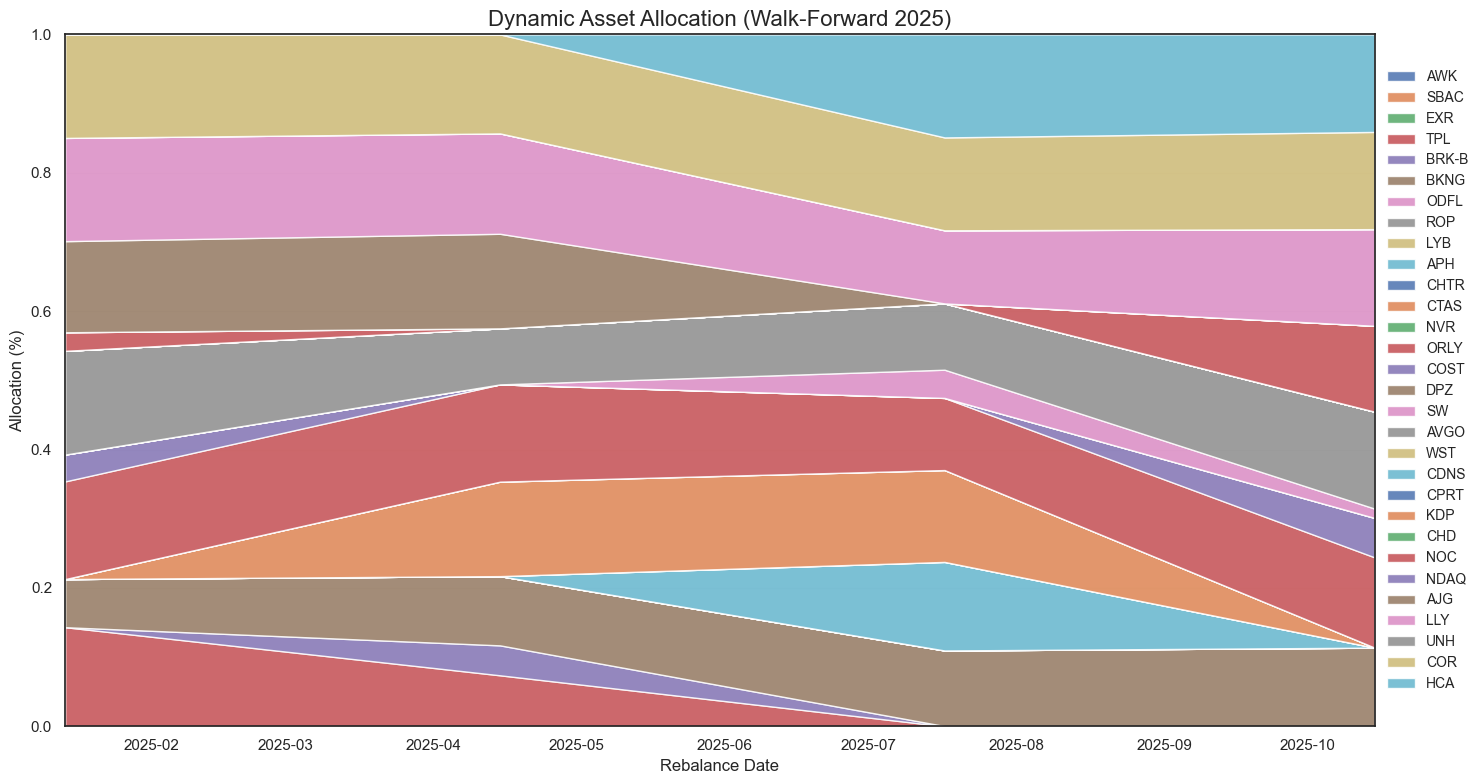

In [90]:
# --- 1. จัดเตรียมข้อมูลน้ำหนักปี 2025 ---
df_weight_history = pd.DataFrame(all_weights_history, index=rebalance_dates, columns=selected_stocks)
df_weight_2025 = df_weight_history[df_weight_history.index.str.startswith('2025')]

# --- 2. ตารางน้ำหนักล่าสุด (ปลายปี 2025) ---
if not df_weight_2025.empty:
    latest_weights = df_weight_2025.iloc[-1]
    latest_weights_df = pd.DataFrame({
        'Ticker': latest_weights.index,
        'Weight': latest_weights.values
    }).sort_values(by='Weight', ascending=False)

    print("\n=== Asset Weights (Latest Rebalance in 2025) ===")
    # แสดงเฉพาะตัวที่มีน้ำหนักมากกว่า 0.1% เพื่อความชัดเจน
    print(latest_weights_df[latest_weights_df['Weight'] > 0.001].to_string(formatters={'Weight': '{:.2%}'.format}, index=False))

    # --- 3. กราฟ Stacked Area Chart (Weights Evolution) ---
    plt.figure(figsize=(15, 8))
    # กรองเฉพาะหุ้นที่มีน้ำหนักเฉลี่ยในปี 2025 เกิน 1% มาแสดงใน Legend (เพื่อไม่ให้ Legend บังรูป)
    important_stocks = df_weight_2025.columns[df_weight_2025.mean() > 0.01]
    
    plt.stackplot(pd.to_datetime(df_weight_2025.index), 
                  df_weight_2025.T, 
                  labels=df_weight_2025.columns,
                  alpha=0.85)

    plt.title('Dynamic Asset Allocation (Walk-Forward 2025)', fontsize=16)
    plt.ylabel('Allocation (%)')
    plt.xlabel('Rebalance Date')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small', ncol=1)
    plt.grid(axis='y', alpha=0.2)
    plt.margins(0,0)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for year 2025 in the weight history.")

In [61]:
cluster_labels

array([19, 18, 19, 26, 21, 20, 18,  9, 21, 20,  1,  1, 12,  5,  5, 26, 26,
       16,  9, 19, 26, 18, 18,  8, 27,  5,  2, 20, 26,  8,  4, 12, 10, 12,
        3,  1,  3, 18, 12,  1, 16,  5, 14, 12,  5, 12, 19, 14, 19,  5, 22,
        9, 27,  5,  6,  4,  8,  5, 27, 21,  5, 26, 19, 12,  3,  5, 23, 29,
        8, 26, 25, 12,  2,  6, 20,  9, 23,  7, 11, 28, 10,  5, 23, 23, 11,
       25, 16,  8,  1, 28,  1,  5, 10, 19,  4, 29, 15, 21, 23, 21,  3,  8,
       19, 20, 10, 21,  7, 12,  9, 21, 29,  4,  1,  6,  9,  8, 16, 15, 30,
       13, 19, 11,  2, 15,  3,  8, 16, 14,  1,  1, 30,  4, 19, 16, 16, 12,
        1, 21, 26,  1, 14, 28,  8,  8,  4,  2,  3,  9, 26,  1,  3,  8,  1,
        1, 19,  1,  7,  6,  3, 12,  8,  9, 21,  7,  1, 10, 21, 21, 21,  5,
        8,  3, 16, 20, 12,  8, 16, 27, 23,  5, 10, 12, 21, 20, 20, 12, 21,
       10,  5,  8,  4, 14,  5, 30, 14,  5, 24, 19,  8, 10, 22, 12,  6, 22,
        8, 28,  5, 10, 25, 19,  8, 12, 27, 18, 20, 12, 12, 19, 21,  8,  5,
        8,  7, 10,  8, 21

In [15]:
valid_tickers

Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'WSM', 'WST', 'WTW', 'WY', 'WYNN', 'XEL', 'XOM', 'YUM', 'ZBH', 'ZBRA'],
      dtype='str', name='Ticker', length=437)

In [14]:
returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,


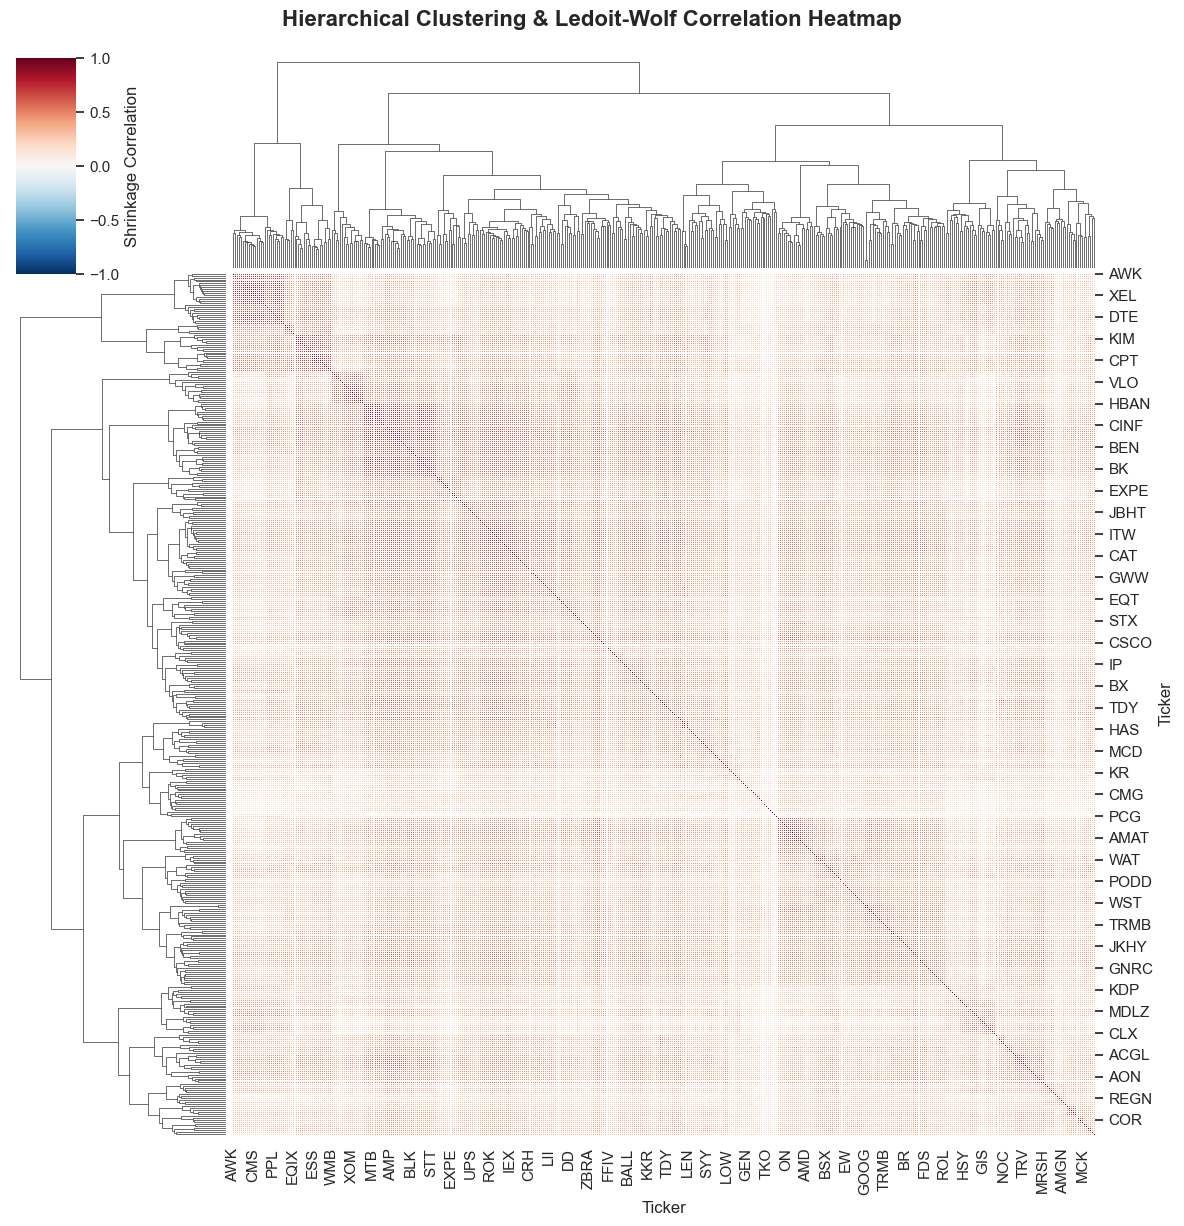

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. ดึงข้อมูล Correlation Matrix จาก GPU กลับมายัง CPU
# (ใช้ตัวแปร corr_matrix_gpu จากสคริปต์ก่อนหน้า)
corr_matrix_cpu = corr_matrix_gpu.cpu().numpy()

# 2. นำรายชื่อหุ้นมาเป็น Index และ Column เพื่อให้แสดงบนแกนกราฟได้
tickers_list = returns.columns.tolist()
corr_df = pd.DataFrame(corr_matrix_cpu, index=valid_tickers, columns=valid_tickers)

# 3. กำหนดสไตล์การแสดงผลของ Seaborn
sns.set_theme(style="white")

# 4. สร้าง Clustermap
# เราสามารถส่ง Linkage Matrix (Z) ที่คำนวณไว้ก่อนหน้าเข้าไปได้โดยตรง
# เพื่อให้กราฟใช้โครงสร้าง Cluster เดียวกับที่เราใช้คัดเลือกหุ้น
g = sns.clustermap(
    corr_df, 
    row_linkage=Z,      # ใช้การจัดกลุ่มเดิมสำหรับแกน Y
    col_linkage=Z,      # ใช้การจัดกลุ่มเดิมสำหรับแกน X
    cmap='RdBu_r',    # โทนสี: แดง (บวก), น้ำเงิน (ลบ/ต่ำ)
    linewidths=0.5,     # เส้นขอบบางๆ ระหว่างเซลล์
    figsize=(12, 12),   # ขนาดของกราฟ
    vmin=-1.0,          # ค่าต่ำสุดของสี
    vmax=1.0,           # ค่าสูงสุดของสี
    cbar_kws={'label': 'Shrinkage Correlation'}
    
)

# 5. ปรับแต่งส่วนหัวและแกนให้สวยงาม
g.fig.suptitle('Hierarchical Clustering & Ledoit-Wolf Correlation Heatmap', 
               y=1.02, fontsize=16, fontweight='bold')

plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)

# แสดงผล
plt.show()